In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
clean_data_df=pd.read_csv("../cleaned_data/cleaned_data_2_20_26.csv")

In [3]:
clean_data_df.head()

,Unnamed: 0,team_name,opponent_name,opponent_pts,team_box_id,game_id,team_id,is_home,win,pts,...,diff_fg3m_average,diff_fg3a_average,diff_days_rest_average,diff_win_percentage_average,diff_wins_last_5_average,diff_wins_last_10_average,diff_win_percentage_last_5_average,diff_win_percentage_last_10_average,diff_pace_rolling_mean_prev_5,diff_pace_average
0,0,76ers,Wizards,107,2140,22000013,1610612755,True,True,113,...,-5.000000,1.000000,0.00,1.000000,-2.000000,-4.00,0.000000,0.000000,-98.0,0.000
1,1,76ers,Knicks,89,2103,22000025,1610612755,False,True,109,...,-1.000000,1.500000,0.00,1.000000,-0.500000,-1.50,0.500000,0.500000,1.0,0.750
2,2,76ers,Cavaliers,118,2100,22000035,1610612755,False,False,94,...,0.333333,5.666667,0.00,0.555556,-0.333333,-1.00,0.333333,0.333333,-1.0,-1.010
3,3,76ers,Raptors,93,2061,22000049,1610612755,True,True,100,...,-2.000000,0.750000,-0.25,0.604167,0.250000,-0.25,0.416667,0.416667,-4.0,-2.625
4,4,76ers,Magic,92,2028,22000064,1610612755,False,True,116,...,0.000000,1.600000,-0.20,0.483333,0.000000,-0.40,0.283333,0.283333,-4.0,-2.600


In [4]:
unneeded_columns=['team_name','opponent_name','opponent_pts',
 'team_box_id', 'game_id', 'team_id',
 'season_year', 'game_date', 'neutral_site',
 'opponent_team_id', 'game_number', 'pts',
 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct',
 'ftm', 'fta', 'ft_pct',
 'oreb', 'dreb', 'reb',
 'ast', 'tov', 'stl', 'blk', 'blka',
 'pf', 'pfd',
 'pace', 'poss', 'minutes_played',
 'total_wins', 'total_losses', 'diff_pts',
 'diff_ast', 'diff_tov', 'total_wins', 'total_losses',
 'diff_pts', 'diff_ast', 'diff_tov',
 'diff_blk', 'diff_blka', 'diff_fgm',
 'diff_fga', 'diff_ftm', 'diff_fta',
 'diff_pf', 'diff_pfd', 'diff_stl',
 'diff_oreb', 'diff_dreb', 'diff_fg3m',
 'diff_fg3a', 'diff_days_rest_average',
 'diff_days_rest_rolling_mean_prev_5',
 'diff_win_percentage_average',
 'diff_win_percentage_last_10_average',
 'diff_win_percentage_last_10_rolling_mean_prev_5',
 'diff_win_percentage_last_5_average',
 'diff_win_percentage_last_5_rolling_mean_prev_5',
 'diff_win_percentage_rolling_mean_prev_5',
 'diff_wins_last_10_average',
 'diff_wins_last_10_rolling_mean_prev_5',
 'diff_wins_last_5_average',
 'diff_wins_last_5_rolling_mean_prev_5',
 'diff_days_rest_rolling_mean_prev_10',
 'diff_win_percentage_last_10_rolling_mean_prev_10',
 'diff_wins_last_10_rolling_mean_prev_10',
 'diff_wins_last_5_rolling_mean_prev_10', 
 'Unnamed: 0'                ]

In [5]:
cols = [col for col in clean_data_df.columns if col not in unneeded_columns]
df = clean_data_df[cols]

In [6]:
in_game_factors = ['win', 'pts', 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct', 'ftm', 'fta', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'tov', 
 'stl', 'blk', 'blka', 'pf', 'pfd', 'pace', 'poss','days_rest', 'wins_last_10', 'wins_last_5', 'win_percentage', 'win_percentage_last_10',
    'win_percentage_last_5', 'is_home', 'is_back_to_back',
    'diff_win_percentage', 'diff_win_percentage_last_10', 'diff_win_percentage_last_5',
    'diff_wins_last_10', 'diff_wins_last_5', 'diff_days_rest',
    'ast_average', 'blk_average', 'blka_average', 'dreb_average', 'fg3a_average',
    'fg3m_average', 'fga_average', 'fgm_average', 'fta_average', 'ftm_average',
    'oreb_average', 'pace_average', 'pf_average', 'pfd_average', 'pts_average',
    'reb_average', 'stl_average', 'tov_average',
    'diff_ast_average', 'diff_blk_average', 'diff_blka_average', 'diff_dreb_average',
    'diff_fg3a_average', 'diff_fg3m_average', 'diff_fga_average', 'diff_fgm_average',
    'diff_fta_average', 'diff_ftm_average', 'diff_oreb_average', 'diff_pace_average',
    'diff_pf_average', 'diff_pfd_average', 'diff_pts_average', 'diff_stl_average',
    'diff_tov_average',
    'ast_rolling_mean_prev_5', 'blk_rolling_mean_prev_5', 'blka_rolling_mean_prev_5',
    'dreb_rolling_mean_prev_5', 'fg3a_rolling_mean_prev_5', 'fg3m_rolling_mean_prev_5',
    'fga_rolling_mean_prev_5', 'fgm_rolling_mean_prev_5', 'fta_rolling_mean_prev_5',
    'ftm_rolling_mean_prev_5', 'oreb_rolling_mean_prev_5', 'pace_rolling_mean_prev_5',
    'pf_rolling_mean_prev_5', 'pfd_rolling_mean_prev_5', 'pts_rolling_mean_prev_5',
    'reb_rolling_mean_prev_5', 'stl_rolling_mean_prev_5', 'tov_rolling_mean_prev_5',
    'diff_ast_rolling_mean_prev_5', 'diff_blk_rolling_mean_prev_5', 'diff_blka_rolling_mean_prev_5',
    'diff_dreb_rolling_mean_prev_5', 'diff_fg3a_rolling_mean_prev_5', 'diff_fg3m_rolling_mean_prev_5',
    'diff_fga_rolling_mean_prev_5', 'diff_fgm_rolling_mean_prev_5', 'diff_fta_rolling_mean_prev_5',
    'diff_ftm_rolling_mean_prev_5', 'diff_oreb_rolling_mean_prev_5', 'diff_pace_rolling_mean_prev_5',
    'diff_pf_rolling_mean_prev_5', 'diff_pfd_rolling_mean_prev_5', 'diff_pts_rolling_mean_prev_5',
    'diff_stl_rolling_mean_prev_5', 'diff_tov_rolling_mean_prev_5'
]

in_game_df = clean_data_df[in_game_factors]


In [7]:
df.head()

,is_home,win,days_rest,is_back_to_back,win_percentage,wins_last_5,wins_last_10,win_percentage_last_5,win_percentage_last_10,diff_days_rest,...,diff_fta_average,diff_pf_average,diff_pfd_average,diff_stl_average,diff_oreb_average,diff_dreb_average,diff_fg3m_average,diff_fg3a_average,diff_pace_rolling_mean_prev_5,diff_pace_average
0,True,True,0.0,0,1.000000,0,0,0.000000,0.000000,0.0,...,7.00,-1.000000,1.000000,4.00,5.000000,2.000000,-5.000000,1.000000,-98.0,0.000
1,False,True,3.0,0,1.000000,1,1,1.000000,1.000000,0.0,...,3.00,-2.500000,2.500000,3.50,2.000000,3.500000,-1.000000,1.500000,1.0,0.750
2,False,False,1.0,1,0.666667,2,2,1.000000,1.000000,0.0,...,4.00,-2.666667,2.666667,1.00,0.333333,1.333333,0.333333,5.666667,-1.0,-1.010
3,True,True,2.0,0,0.750000,2,2,0.666667,0.666667,-1.0,...,7.75,-5.250000,5.250000,0.25,0.000000,3.000000,-2.000000,0.750000,-4.0,-2.625
4,False,True,2.0,0,0.800000,3,3,0.750000,0.750000,0.0,...,5.00,-2.600000,2.600000,1.20,-0.600000,4.200000,0.000000,1.600000,-4.0,-2.600


In [8]:
in_game_df.head()

,win,pts,fgm,fga,fg_pct,fg3m,fg3a,fg3_pct,ftm,fta,...,diff_fgm_rolling_mean_prev_5,diff_fta_rolling_mean_prev_5,diff_ftm_rolling_mean_prev_5,diff_oreb_rolling_mean_prev_5,diff_pace_rolling_mean_prev_5,diff_pf_rolling_mean_prev_5,diff_pfd_rolling_mean_prev_5,diff_pts_rolling_mean_prev_5,diff_stl_rolling_mean_prev_5,diff_tov_rolling_mean_prev_5
0,True,113,41,87,0.471,8,28,0.286,23,30,...,0,0,0,0,-98.0,0,0,0,0,0
1,True,109,41,88,0.466,11,31,0.355,16,22,...,2,7,7,5,1.0,-1,1,6,4,-2
2,False,94,33,79,0.418,12,37,0.324,16,22,...,5,3,3,2,-1.0,-2,2,13,3,-3
3,True,100,32,84,0.381,8,31,0.258,28,33,...,-1,4,3,0,-4.0,-2,2,0,1,0
4,True,116,44,91,0.484,15,33,0.455,13,15,...,-1,7,6,0,-4.0,-5,5,2,0,0


In [9]:
### EDA

In [10]:
# HOME vs AWAY Performance
print("="*80)
print("HOME VS AWAY ANALYSIS")
print("="*80)

home_win_pct = in_game_df[in_game_df['is_home'] == 1]['win'].mean()
away_win_pct = in_game_df[in_game_df['is_home'] == 0]['win'].mean()

print(f"Home win %: {home_win_pct:.2%}")
print(f"Away win %: {away_win_pct:.2%}")
print(f"Home advantage: +{(home_win_pct - away_win_pct)*100:.1f}%")

HOME VS AWAY ANALYSIS
Home win %: 55.10%
Away win %: 44.92%
Home advantage: +10.2%


In [11]:
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Convert win to binary if needed
if in_game_df['win'].dtype == bool:
    in_game_df['win'] = in_game_df['win'].astype(int)

In [12]:
##  Statistical Summary by Win/Loss 
print("\n" + "="*80)
print("STATISTICAL SUMMARY BY WIN/LOSS")
print("="*80)

# Split data by win/loss
wins = in_game_df[in_game_df['win'] == 1]
losses = in_game_df[in_game_df['win'] == 0]

# Select numeric columns for comparison
numeric_cols = in_game_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('win')

# Create comparison dataframe
comparison_stats = pd.DataFrame({
    'Wins_Mean': wins[numeric_cols].mean(),
    'Wins_Std': wins[numeric_cols].std(),
    'Losses_Mean': losses[numeric_cols].mean(),
    'Losses_Std': losses[numeric_cols].std(),
    'Difference': wins[numeric_cols].mean() - losses[numeric_cols].mean(),
    'Diff_Percent': ((wins[numeric_cols].mean() - losses[numeric_cols].mean()) / losses[numeric_cols].mean().abs()) * 100
})

# Add t-test p-values
p_values = []
for col in numeric_cols:
    if wins[col].notna().sum() > 0 and losses[col].notna().sum() > 0:
        t_stat, p_val = stats.ttest_ind(wins[col].dropna(), losses[col].dropna())
        p_values.append(p_val)
    else:
        p_values.append(np.nan)

comparison_stats['P_Value'] = p_values
comparison_stats['Significant'] = comparison_stats['P_Value'] < 0.05

# Sort by absolute difference
comparison_stats = comparison_stats.sort_values('Difference', key=abs, ascending=False)

print("\nTop features that differentiate wins from losses:")
print(comparison_stats.head(20).round(4))


STATISTICAL SUMMARY BY WIN/LOSS

Top features that differentiate wins from losses:
                              Wins_Mean  Wins_Std  Losses_Mean  Losses_Std  \
pts                            119.5157   11.0079     107.2823     11.1232   
fgm                             43.7355    4.8587      39.4219      4.7070   
dreb                            35.3569    5.1629      31.3876      4.8766   
reb                             45.8948    6.4463      42.0231      6.2390   
diff_pts_average                 1.9268    5.3603      -1.9151      5.6427   
ast                             27.3380    5.1256      24.1199      4.6397   
diff_pts_rolling_mean_prev_5     1.3567    7.8309      -1.3507      8.1690   
fg3m                            13.8992    4.0000      11.7649      3.5331   
pts_average                    113.8783    5.0223     112.0489      5.0642   
ftm                             18.1455    6.0741      16.6736      5.5519   
diff_wins_last_10                0.7021    2.7685      -0.


CORRELATION WITH WIN

Features most positively correlated with winning:
pts                    0.4838
diff_win_percentage    0.4629
fg_pct                 0.4561
fgm                    0.4111
dreb                   0.3676
win_percentage         0.3640
fg3_pct                0.3569
diff_pts_average       0.3296
ast                    0.3127
reb                    0.2919
Name: win, dtype: float64

Features most negatively correlated with winning:
pf                              -0.0677
diff_pace_average               -0.0694
diff_blka_rolling_mean_prev_5   -0.0789
blka_rolling_mean_prev_5        -0.0872
tov                             -0.0930
tov_average                     -0.1046
diff_tov_average                -0.1058
diff_blka_average               -0.1356
blka_average                    -0.1390
blka                            -0.1538
Name: win, dtype: float64


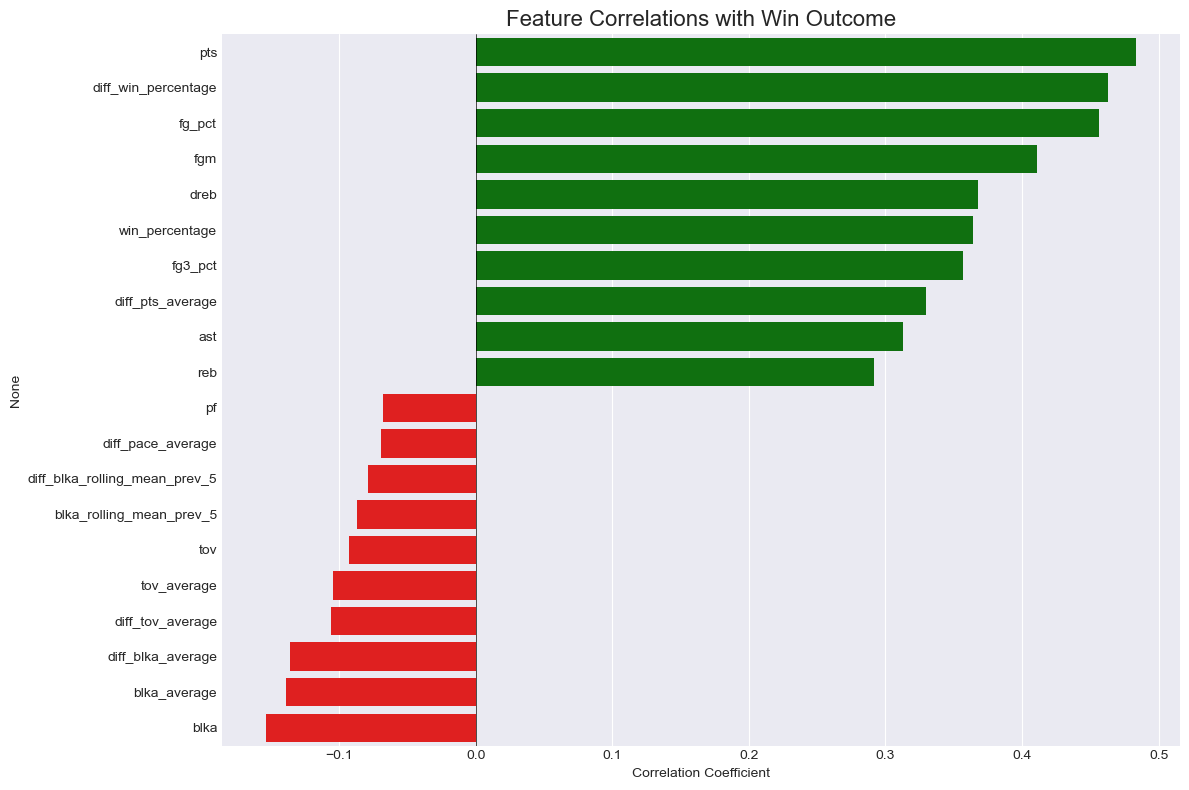

In [13]:
# Correlation Analysis
print("\n" + "="*80)
print("CORRELATION WITH WIN")
print("="*80)

correlations = in_game_df[numeric_cols + ['win']].corr()['win'].sort_values(ascending=False)
print("\nFeatures most positively correlated with winning:")
print(correlations.head(11)[1:].round(4))  # Skip win itself

print("\nFeatures most negatively correlated with winning:")
print(correlations.tail(10).round(4))

# Visualize top correlations
plt.figure(figsize=(12, 8))
top_corr = pd.concat([correlations.head(11)[1:], correlations.tail(10)])
colors = ['green' if x > 0 else 'red' for x in top_corr.values]
sns.barplot(x=top_corr.values, y=top_corr.index, palette=colors)
plt.title('Feature Correlations with Win Outcome', fontsize=16)
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()


CORRELATION HEATMAP - TOP FEATURES


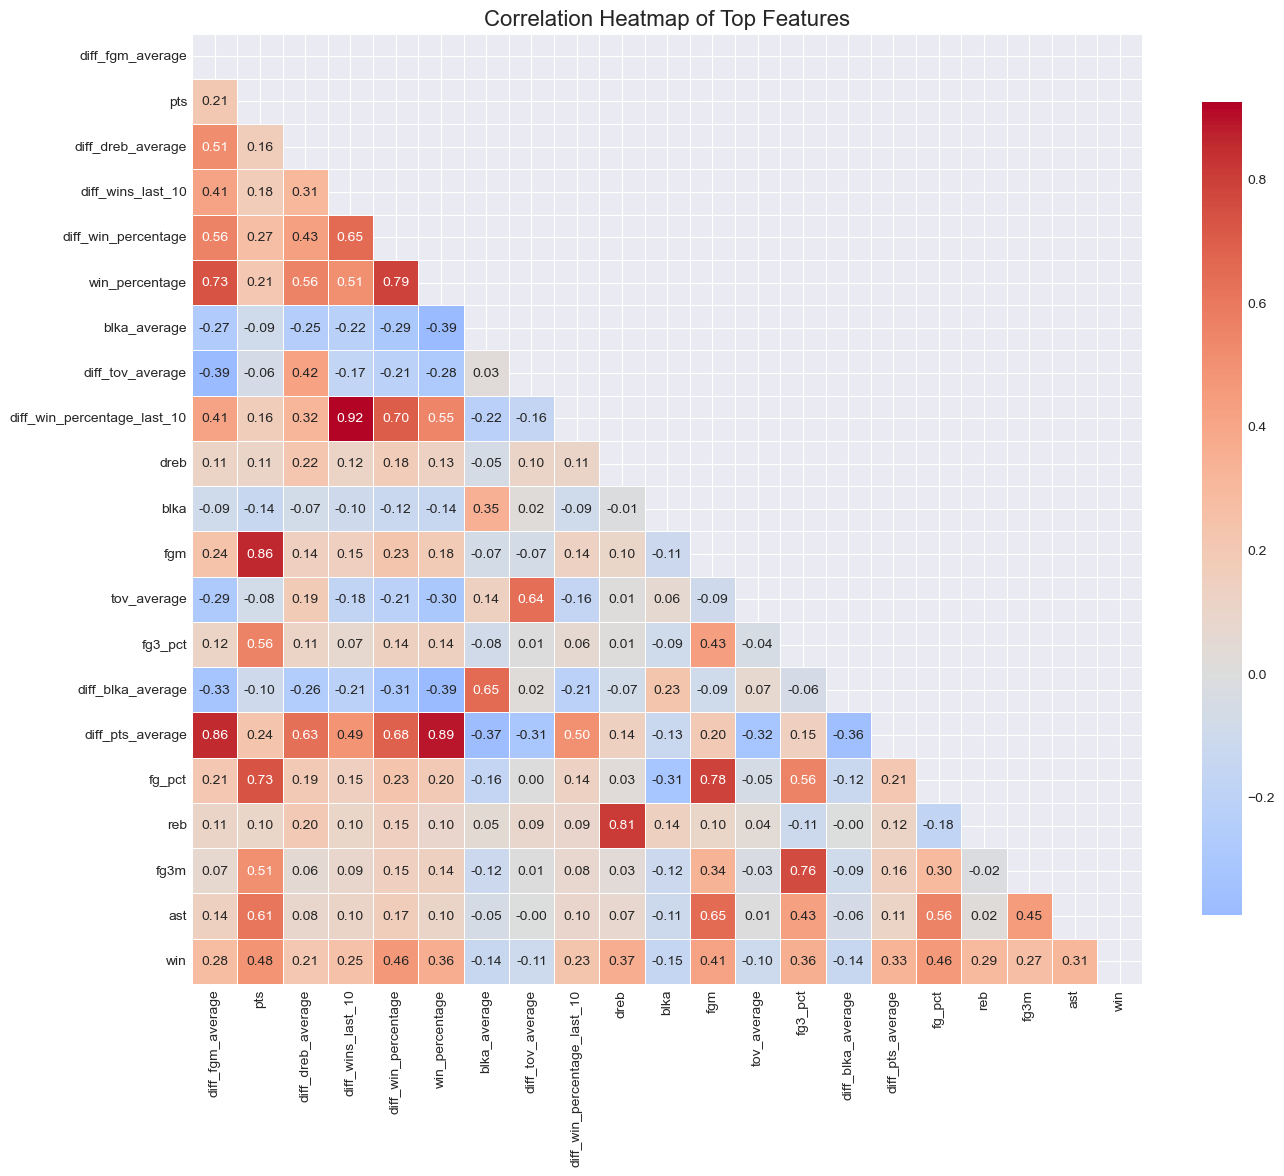

In [14]:
# Correlation Heatmap (for top features)
print("\n" + "="*80)
print("CORRELATION HEATMAP - TOP FEATURES")
print("="*80)

# Select top features based on correlation with win
top_features = correlations.head(16)[1:].index.tolist() + correlations.tail(5).index.tolist()
top_features = list(set(top_features))  # Remove duplicates

plt.figure(figsize=(14, 12))
corr_matrix = in_game_df[top_features + ['win']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Top Features', fontsize=16)
plt.tight_layout()
plt.show()


In [15]:
print("="*80)
print("OUTLIER ANALYSIS WITH BOX PLOTS")
print("="*80)

# Select key statistics for outlier analysis
key_stats = ['pts', 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct', 'ftm', 'fta', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'tov', 
 'stl', 'blk', 'blka', 'pf', 'pfd', 'pace', 'poss','days_rest']
available_stats = [stat for stat in key_stats if stat in in_game_df.columns]

print(f"\nAnalyzing {len(available_stats)} key statistics")

# 1. Function to detect outliers using IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# 2. Function to detect outliers using Z-score method
def detect_outliers_zscore(df, column, threshold=3):
    z_scores = np.abs(stats.zscore(df[column].dropna()))
    outliers = df.iloc[np.where(z_scores > threshold)[0]]
    return outliers

# 3. Create comprehensive outlier analysis
print("\n" + "="*80)
print("OUTLIER DETECTION RESULTS")
print("="*80)

outlier_summary = []

for stat in available_stats:
    # IQR method
    outliers_iqr, lower, upper = detect_outliers_iqr(in_game_df, stat)
    
    # Z-score method
    outliers_zscore = detect_outliers_zscore(in_game_df, stat)
    
    # Calculate statistics
    stat_mean = in_game_df[stat].mean()
    stat_std = in_game_df[stat].std()
    stat_min = in_game_df[stat].min()
    stat_max = in_game_df[stat].max()
    
    # Store summary
    outlier_summary.append({
        'Statistic': stat,
        'Mean': stat_mean,
        'Std': stat_std,
        'Min': stat_min,
        'Max': stat_max,
        'IQR_Outliers': len(outliers_iqr),
        'IQR_Outlier_%': (len(outliers_iqr) / len(in_game_df)) * 100,
        'ZScore_Outliers': len(outliers_zscore),
        'ZScore_Outlier_%': (len(outliers_zscore) / len(in_game_df)) * 100,
        'Lower_Bound': lower,
        'Upper_Bound': upper
    })
    
    # Print significant findings
    if len(outliers_iqr) > 0:
        print(f"\n📊 {stat.upper()} - Outliers found:")
        print(f"   Range: {stat_min:.2f} to {stat_max:.2f}")
        print(f"   Mean: {stat_mean:.2f} ± {stat_std:.2f}")
        print(f"   IQR outliers: {len(outliers_iqr)} ({len(outliers_iqr)/len(in_game_df)*100:.2f}%)")
        print(f"   Normal range: [{lower:.2f}, {upper:.2f}]")
        
        # Check if outliers are more likely to be wins
        if len(outliers_iqr) > 0:
            outlier_win_rate = outliers_iqr['win'].mean()
            normal_data = in_game_df[~in_game_df.index.isin(outliers_iqr.index)]
            normal_win_rate = normal_data['win'].mean()
            print(f"   Outlier win rate: {outlier_win_rate:.2%}")
            print(f"   Normal win rate: {normal_win_rate:.2%}")
            print(f"   Impact: {(outlier_win_rate - normal_win_rate)*100:+.1f}%")


OUTLIER ANALYSIS WITH BOX PLOTS

Analyzing 23 key statistics

OUTLIER DETECTION RESULTS

📊 PTS - Outliers found:
   Range: 66.00 to 176.00
   Mean: 113.40 ± 12.64
   IQR outliers: 87 (0.64%)
   Normal range: [79.50, 147.50]
   Outlier win rate: 55.17%
   Normal win rate: 49.97%
   Impact: +5.2%

📊 FGM - Outliers found:
   Range: 22.00 to 65.00
   Mean: 41.58 ± 5.25
   IQR outliers: 103 (0.76%)
   Normal range: [27.50, 55.50]
   Outlier win rate: 70.87%
   Normal win rate: 49.84%
   Impact: +21.0%

📊 FGA - Outliers found:
   Range: 64.00 to 122.00
   Mean: 88.67 ± 7.09
   IQR outliers: 204 (1.50%)
   Normal range: [70.50, 106.50]
   Outlier win rate: 43.14%
   Normal win rate: 50.10%
   Impact: -7.0%

📊 FG_PCT - Outliers found:
   Range: 0.28 to 0.69
   Mean: 0.47 ± 0.05
   IQR outliers: 78 (0.57%)
   Normal range: [0.32, 0.62]
   Outlier win rate: 69.23%
   Normal win rate: 49.89%
   Impact: +19.3%

📊 FG3M - Outliers found:
   Range: 2.00 to 29.00
   Mean: 12.83 ± 3.92
   IQR outliers:

In [16]:
# Create summary dataframe
outlier_df = pd.DataFrame(outlier_summary)
print("\n" + "="*80)
print("OUTLIER SUMMARY TABLE")
print("="*80)
print(outlier_df.round(2).to_string(index=False))


OUTLIER SUMMARY TABLE
Statistic   Mean   Std   Min    Max  IQR_Outliers  IQR_Outlier_%  ZScore_Outliers  ZScore_Outlier_%  Lower_Bound  Upper_Bound
      pts 113.40 12.64 66.00 176.00            87           0.64               37              0.27        79.50       147.50
      fgm  41.58  5.25 22.00  65.00           103           0.76               35              0.26        27.50        55.50
      fga  88.67  7.09 64.00 122.00           204           1.50               78              0.57        70.50       106.50
   fg_pct   0.47  0.05  0.28   0.69            78           0.57               41              0.30         0.32         0.62
     fg3m  12.83  3.92  2.00  29.00           179           1.32               53              0.39         2.50        22.50
     fg3a  35.55  6.96 10.00  65.00           139           1.02               42              0.31        17.50        53.50
  fg3_pct   0.36  0.08  0.07   0.68           113           0.83               38              


CREATING BOX PLOTS


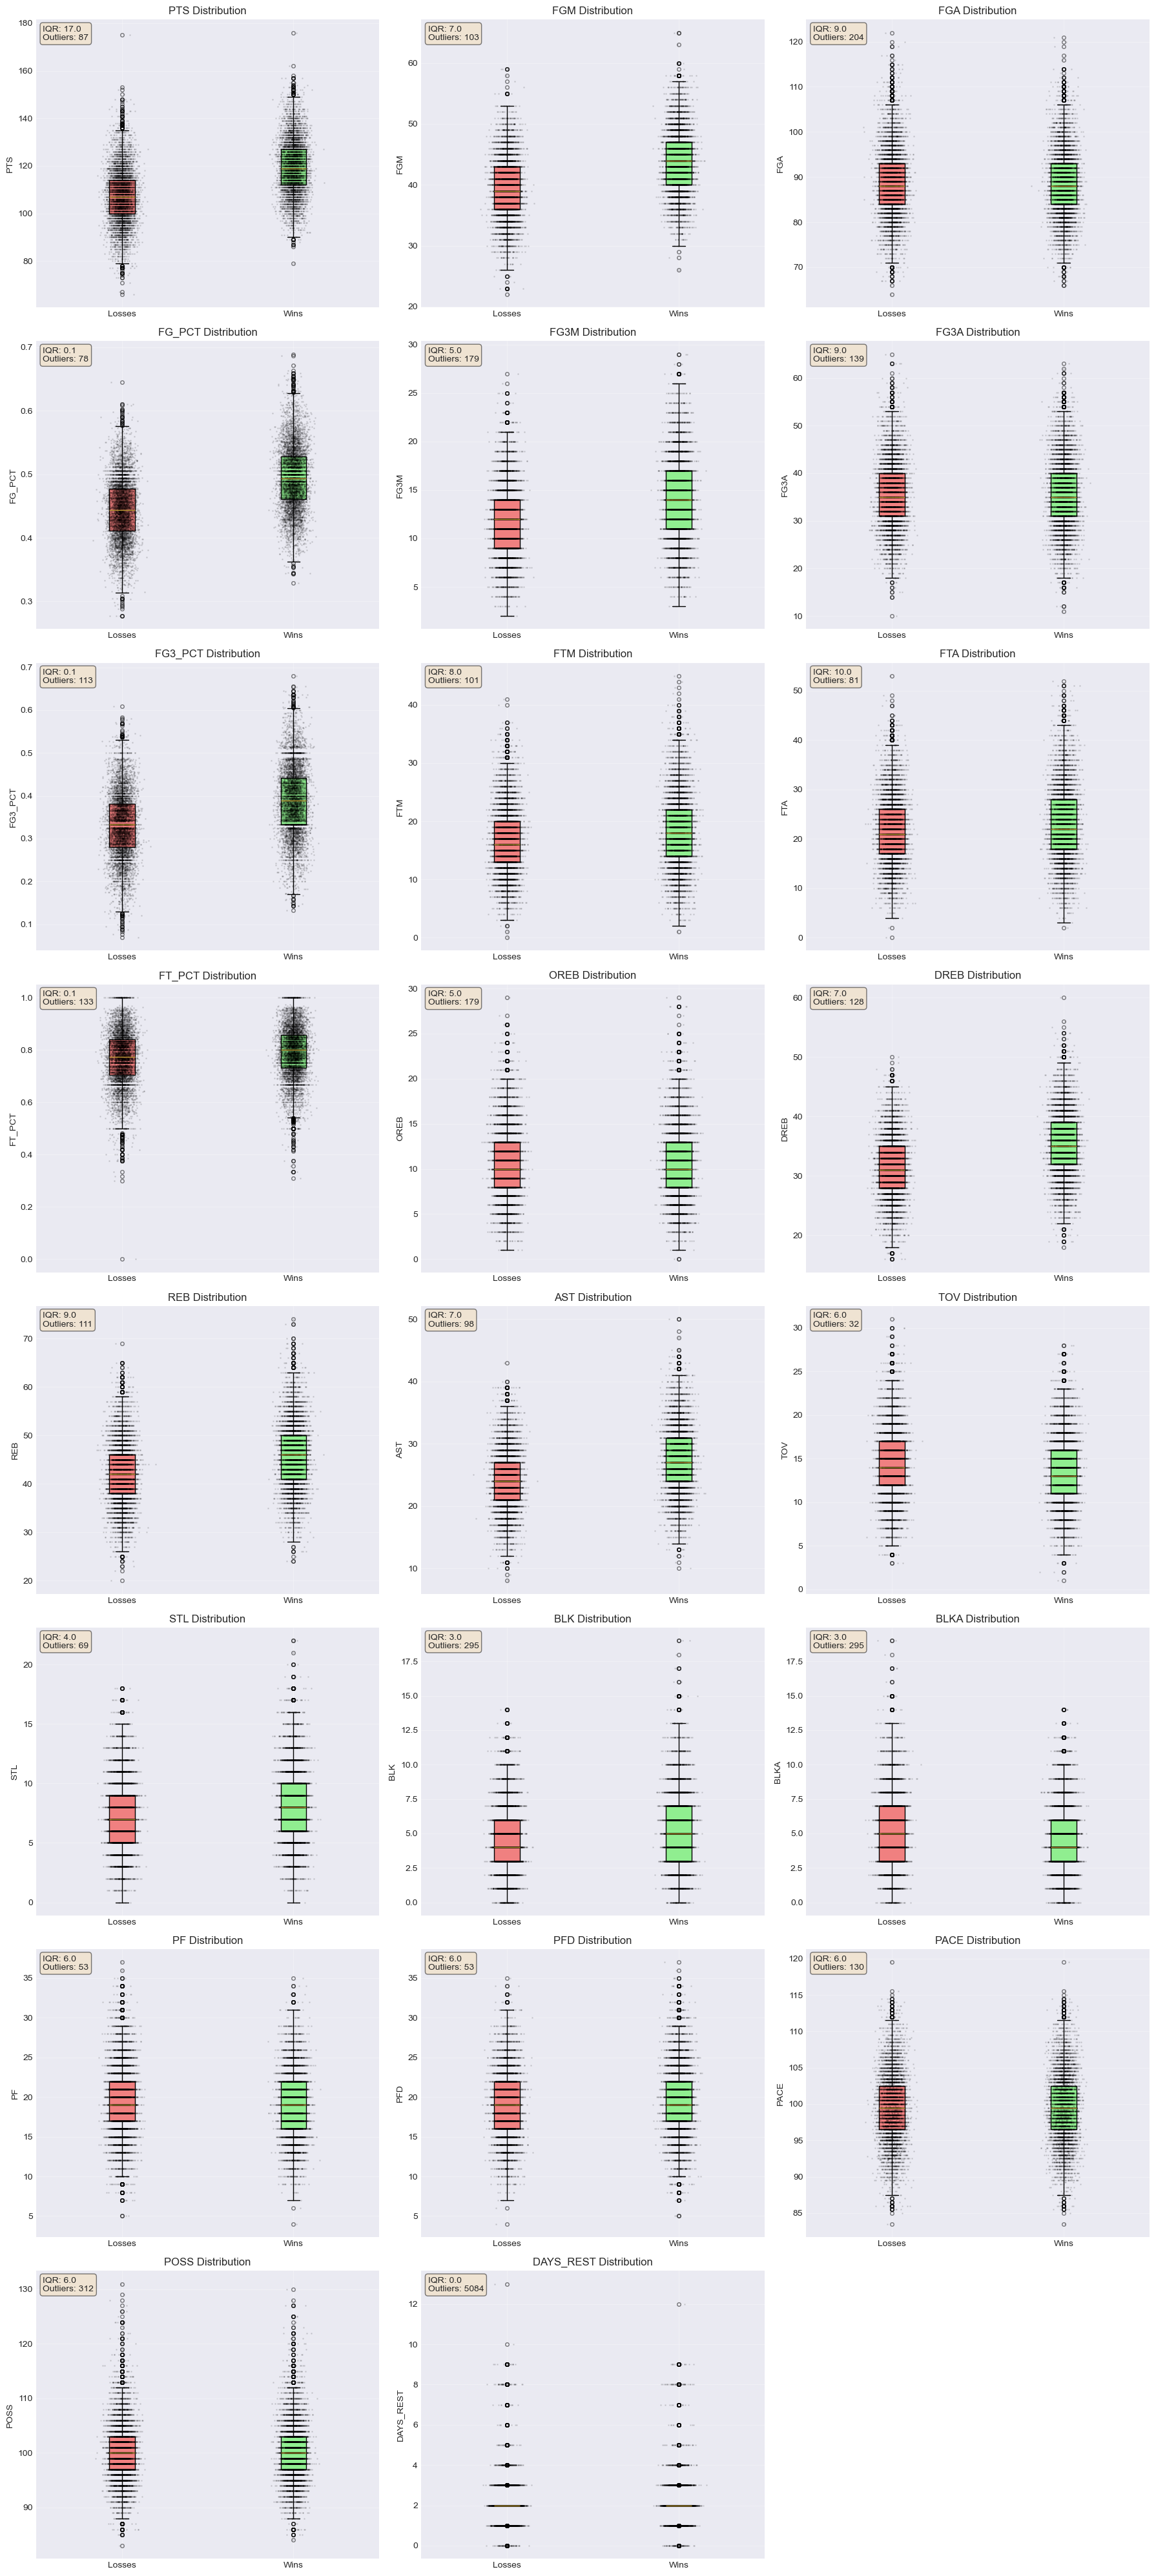

In [17]:
# Create box plots for all key statistics
print("\n" + "="*80)
print("CREATING BOX PLOTS")
print("="*80)

# Determine grid size for subplots
n_stats = len(available_stats)
n_cols = 3
n_rows = (n_stats + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))


# Flatten axes array for easy iteration
if n_rows > 1:
    axes = axes.flatten()
else:
    axes = [axes] if n_cols == 1 else axes

# Create box plots
for idx, stat in enumerate(available_stats):
    if idx < len(axes):
        # Create box plot split by win/loss
        data_to_plot = [
            in_game_df[in_game_df['win'] == 0][stat].dropna(),
            in_game_df[in_game_df['win'] == 1][stat].dropna()
        ]
        
        bp = axes[idx].boxplot(data_to_plot, labels=['Losses', 'Wins'], 
                               patch_artist=True, showfliers=True)
        
        # Color the boxes
        bp['boxes'][0].set_facecolor('lightcoral')
        bp['boxes'][1].set_facecolor('lightgreen')
        
        # Color the outliers
        for flier in bp['fliers']:
            flier.set(marker='o', markersize=4, alpha=0.5)
        
        # Add individual points (jittered) for better visualization
        for i, data in enumerate(data_to_plot):
            y = data
            x = np.random.normal(i+1, 0.04, size=len(y))
            axes[idx].plot(x, y, 'k.', alpha=0.1, markersize=2)
        
        # Add statistics as text
        q1 = in_game_df[stat].quantile(0.25)
        q3 = in_game_df[stat].quantile(0.75)
        iqr = q3 - q1
        axes[idx].text(0.02, 0.98, f'IQR: {iqr:.1f}\nOutliers: {outlier_df.iloc[idx]["IQR_Outliers"]:.0f}', 
                      transform=axes[idx].transAxes, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        axes[idx].set_title(f'{stat.upper()} Distribution', fontsize=12)
        axes[idx].set_ylabel(stat.upper())
        axes[idx].grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(len(available_stats), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


BOX PLOTS: DIFFERENTIAL STATISTICS


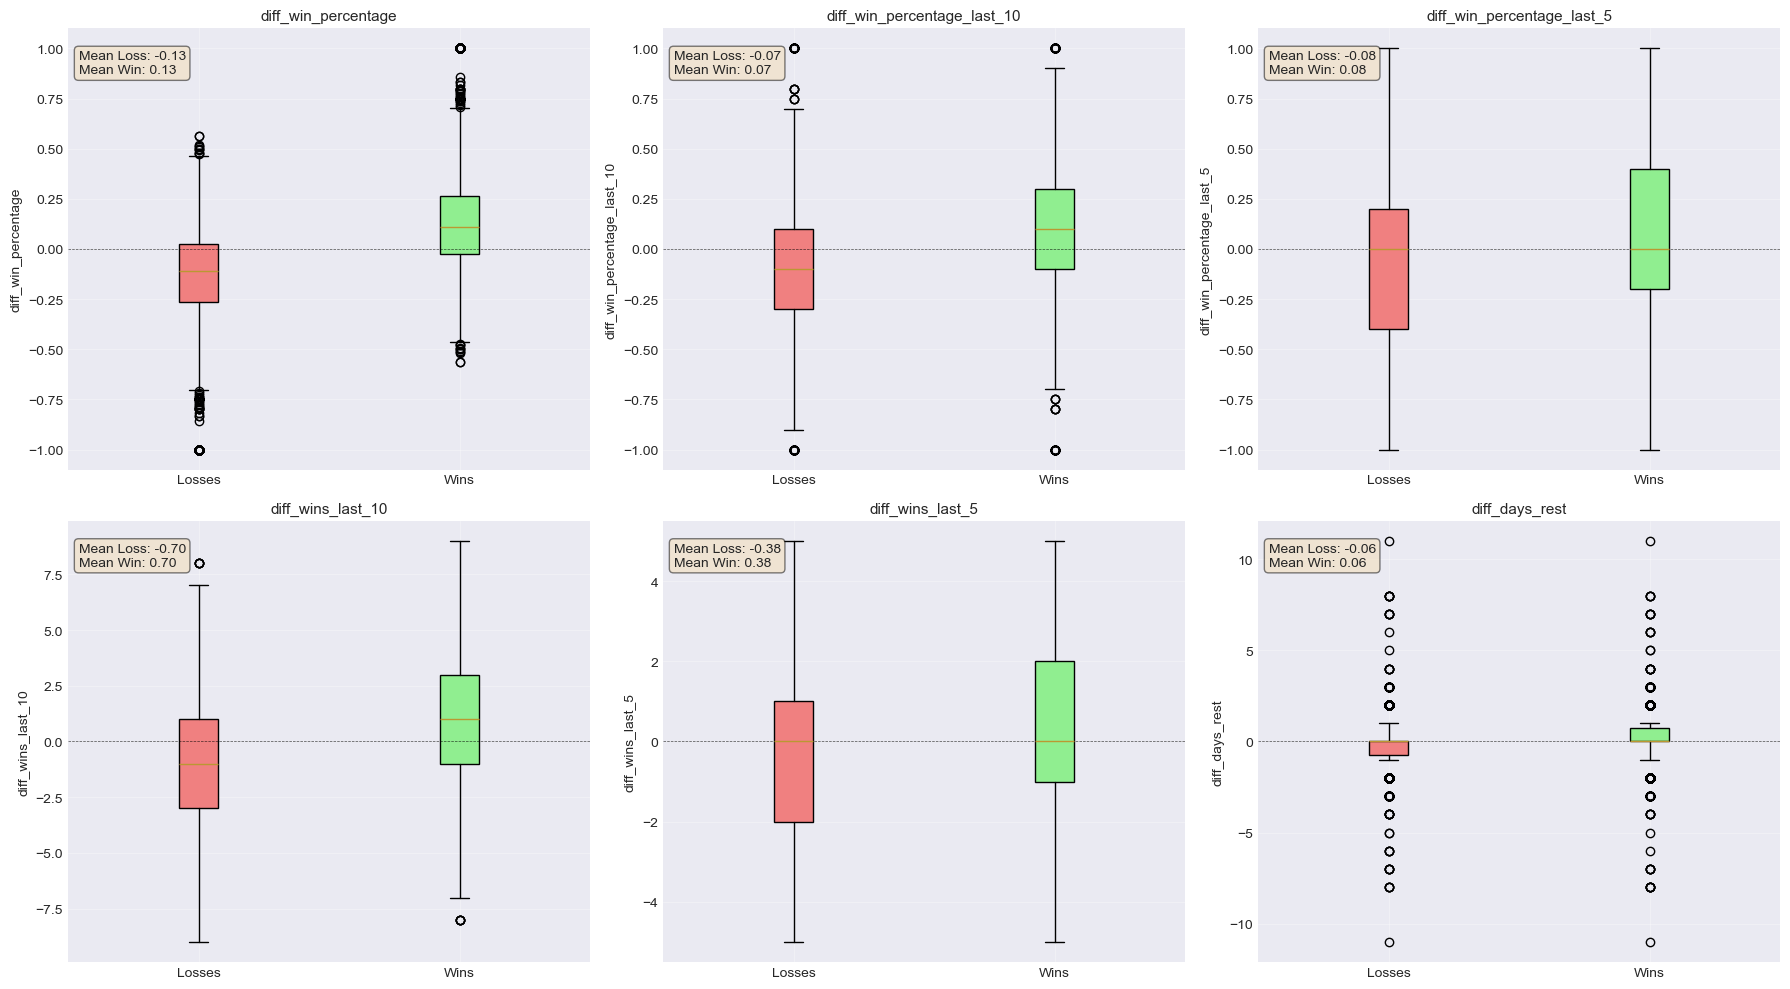

In [18]:
#  Separate box plots for differential stats
print("\n" + "="*80)
print("BOX PLOTS: DIFFERENTIAL STATISTICS")
print("="*80)

diff_stats = [col for col in in_game_df.columns if col.startswith('diff_') and 'average' not in col and 'rolling' not in col]

if diff_stats:
    n_diff = len(diff_stats)
    n_rows = (n_diff + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
    
    
    if n_rows > 1:
        axes = axes.flatten()
    
    for idx, stat in enumerate(diff_stats):
        if idx < len(axes):
            data_to_plot = [
                in_game_df[in_game_df['win'] == 0][stat].dropna(),
                in_game_df[in_game_df['win'] == 1][stat].dropna()
            ]
            
            bp = axes[idx].boxplot(data_to_plot, labels=['Losses', 'Wins'],
                                   patch_artist=True, showfliers=True)
            
            bp['boxes'][0].set_facecolor('lightcoral')
            bp['boxes'][1].set_facecolor('lightgreen')
            
            # Add horizontal line at zero
            axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.7)
            
            # Add mean values
            mean_loss = in_game_df[in_game_df['win'] == 0][stat].mean()
            mean_win = in_game_df[in_game_df['win'] == 1][stat].mean()
            axes[idx].text(0.02, 0.95, f'Mean Loss: {mean_loss:.2f}\nMean Win: {mean_win:.2f}',
                          transform=axes[idx].transAxes, verticalalignment='top',
                          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            axes[idx].set_title(f'{stat}', fontsize=11)
            axes[idx].set_ylabel(stat)
            axes[idx].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(diff_stats), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()


BOX PLOTS: ROLLING AVERAGES


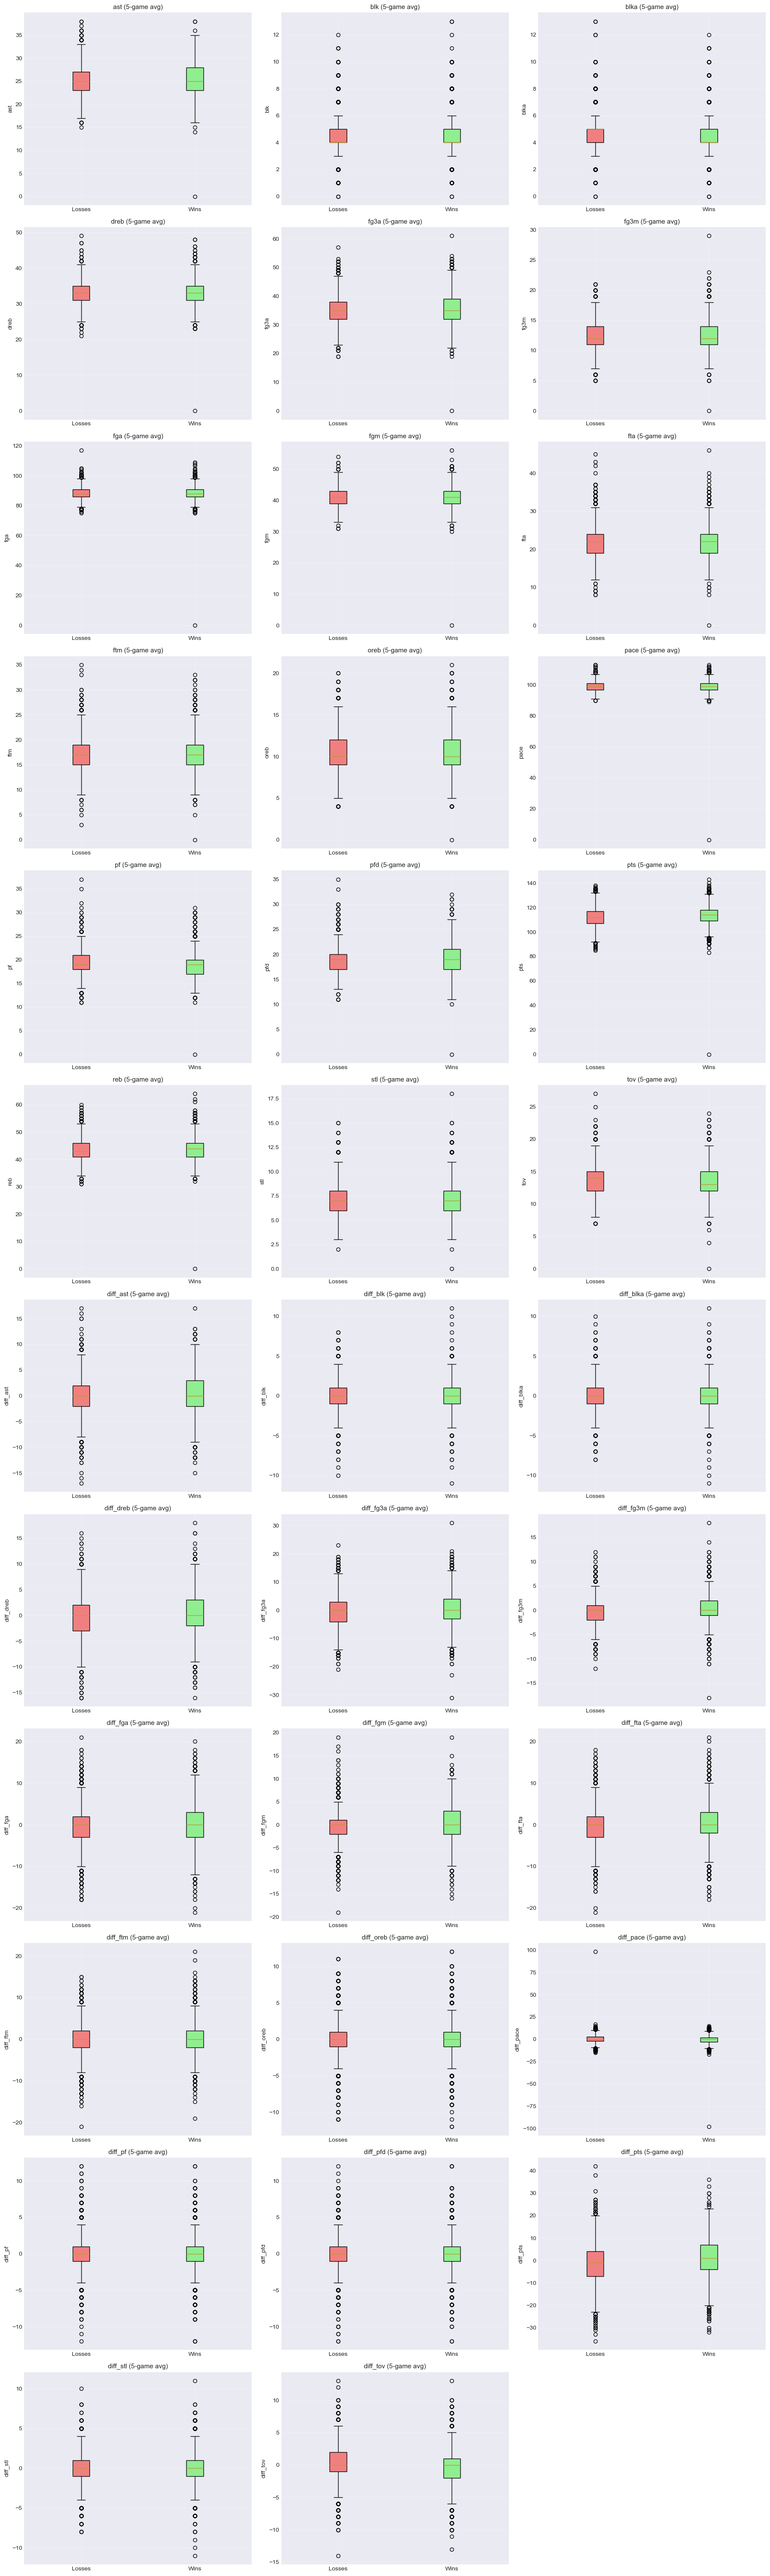

In [19]:
#  Rolling stats box plots
print("\n" + "="*80)
print("BOX PLOTS: ROLLING AVERAGES")
print("="*80)

rolling_stats = [col for col in in_game_df.columns if 'rolling_mean_prev_5' in col]

if rolling_stats:
    n_rolling = len(rolling_stats)
    n_rows = (n_rolling + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
    
    
    if n_rows > 1:
        axes = axes.flatten()
    
    for idx, stat in enumerate(rolling_stats):
        if idx < len(axes):
            data_to_plot = [
                in_game_df[in_game_df['win'] == 0][stat].dropna(),
                in_game_df[in_game_df['win'] == 1][stat].dropna()
            ]
            
            bp = axes[idx].boxplot(data_to_plot, labels=['Losses', 'Wins'],
                                   patch_artist=True, showfliers=True)
            
            bp['boxes'][0].set_facecolor('lightcoral')
            bp['boxes'][1].set_facecolor('lightgreen')
            
            short_name = stat.replace('_rolling_mean_prev_5', '')
            axes[idx].set_title(f'{short_name} (5-game avg)', fontsize=11)
            axes[idx].set_ylabel(short_name)
            axes[idx].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(rolling_stats), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

In [ ]:
## old code, will delete

In [3]:
# ============================================
# STEP 2: LOAD INDIVIDUAL TABLES
# ============================================
game_df = pd.read_csv(r"C:\Users\56383\Downloads\game.csv")
team_df = pd.read_csv(r"C:\Users\56383\Downloads\team.csv")
player_df = pd.read_csv(r"C:\Users\56383\Downloads\player.csv")
draft_df = pd.read_csv(r"C:\Users\56383\Downloads\draft.csv")
team_box_score_df = pd.read_csv(r"C:\Users\56383\Downloads\team_box_score.csv")
player_box_score_df = pd.read_csv(r"C:\Users\56383\Downloads\player_box_score.csv")

In [4]:
print(f"✅ TEAM TABLE: {len(team_df):,} rows, {len(team_df.columns)} columns")
print(f"   Columns: {', '.join(team_df.columns[:5])}...")

✅ TEAM TABLE: 30 rows, 8 columns
   Columns: team_id, team_name, team_abbreviation, team_city, team_conference...


In [5]:
display(team_box_score_df.head())

,team_box_id,game_id,team_id,is_home,win,pts,fgm,fga,fg_pct,fg3m,...,oreb,dreb,reb,ast,tov,stl,blk,blka,pf,pfd
0,1,22001066,1610612737,True,True,124,49,90,0.544,7,...,11,45,56,32,13,10,8,5,16,18
1,2,22001077,1610612762,False,True,121,41,86,0.477,18,...,9,41,50,28,16,9,3,5,14,22
2,3,22001076,1610612757,True,True,132,46,87,0.529,18,...,11,40,51,24,14,3,6,2,16,20
3,4,22001071,1610612750,True,True,136,49,90,0.544,17,...,11,27,38,35,10,11,4,5,22,19
4,5,22001067,1610612751,True,True,123,47,83,0.566,16,...,4,33,37,35,12,9,9,5,20,14


In [6]:
display(team_df.head())

,team_id,team_name,team_abbreviation,team_city,team_conference,team_division,team_code,team_slug
0,1610612737,Hawks,ATL,Atlanta,East,Southeast,hawks,hawks
1,1610612738,Celtics,BOS,Boston,East,Atlantic,celtics,celtics
2,1610612739,Cavaliers,CLE,Cleveland,East,Central,cavaliers,cavaliers
3,1610612740,Pelicans,NOP,New Orleans,West,Southwest,pelicans,pelicans
4,1610612741,Bulls,CHI,Chicago,East,Central,bulls,bulls


In [7]:
display(game_df.head())

,game_id,game_date,season_year,minutes_played,home_team_id,away_team_id,home_score,away_score,overtime,neutral_site
0,22001066,2021-05-16,2020-21,48,1610612737,1610612745,124,95,0,0
1,22001076,2021-05-16,2020-21,48,1610612757,1610612743,132,116,0,0
2,22001071,2021-05-16,2020-21,48,1610612750,1610612742,136,121,0,0
3,22001067,2021-05-16,2020-21,48,1610612751,1610612739,123,109,0,0
4,22001070,2021-05-16,2020-21,48,1610612744,1610612763,113,101,0,0


In [8]:
#create df by merge team_df[["team_id","team_name"]], team_box_score_df, to add the team_name from team_df to team_box_score_df
df=pd.merge(team_df[["team_id","team_name"]], team_box_score_df, on = "team_id", how="left")
print("step 1")
print("="*10)
display(df)
#
print("\n\n")
print("step 2")
print("="*10)

#add game_date from game_df to df
df=pd.merge(game_df[["game_id","game_date"]], df, on = "game_id", how="left")
display(df)

#Adding away team name to df 
# away team name is present in game_df, want to get into df by merging with df on game_id

#step 3.1) copied just game_id and away_team id from game_df and renamed to df_tmp
df_tmp = game_df[["game_id","away_team_id"]].copy()
# step 3.2) renamed away_team_id in tmp_df to team_id. Will need team id to get team name from team_df
df_tmp= df_tmp.rename(columns={"away_team_id":"team_id"})
# step 3.3) merged df_tmp, which has team_id (which is really away team id) and team_df which will give us the team name
df_away_team_name=pd.merge(df_tmp, team_df[["team_id","team_name"]], on = "team_id", how="left")
# step 3.4) selected just game_id and team_name from df_away_team_name so we can mearge into main dataframe called df
df_away_team=df_away_team_name[["game_id","team_name"]]
# step 3.5) renamed df_away_team team name to away_team_name
df_away_team=df_away_team.rename(columns={"team_name":"away_team_name"})
#step 3.6) merged df_away_team into df so df now has away_team_name
df=pd.merge(df, df_away_team, on = "game_id", how="left")
df

step 1


,team_id,team_name,team_box_id,game_id,is_home,win,pts,fgm,fga,fg_pct,...,oreb,dreb,reb,ast,tov,stl,blk,blka,pf,pfd
0,1610612737,Hawks,1,22001066,True,True,124,49,90,0.544,...,11,45,56,32,13,10,8,5,16,18
1,1610612737,Hawks,59,22001049,True,True,116,41,94,0.436,...,12,37,49,19,7,9,4,6,16,16
2,1610612737,Hawks,81,22001042,True,True,120,44,86,0.512,...,7,44,51,22,14,4,5,1,21,20
3,1610612737,Hawks,116,22001026,True,True,125,46,96,0.479,...,13,42,55,23,12,4,6,8,17,21
4,1610612737,Hawks,182,22001000,False,False,126,48,94,0.511,...,10,24,34,27,12,8,6,4,17,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13591,1610612766,Hornets,13459,22500138,True,False,107,42,83,0.506,...,12,29,41,24,21,5,6,7,22,19
13592,1610612766,Hornets,13490,22500124,False,False,117,40,90,0.444,...,9,32,41,26,18,9,3,2,18,16
13593,1610612766,Hornets,13513,22500109,False,True,139,47,92,0.511,...,11,41,52,30,12,12,4,4,16,27
13594,1610612766,Hornets,13536,22500102,False,False,121,43,89,0.483,...,13,32,45,30,17,6,3,5,26,25





step 2


,game_id,game_date,team_id,team_name,team_box_id,is_home,win,pts,fgm,fga,...,oreb,dreb,reb,ast,tov,stl,blk,blka,pf,pfd
0,22001066,2021-05-16,1610612737,Hawks,1,True,True,124,49,90,...,11,45,56,32,13,10,8,5,16,18
1,22001066,2021-05-16,1610612745,Rockets,30,False,False,95,31,92,...,11,32,43,25,16,8,5,8,18,16
2,22001076,2021-05-16,1610612743,Nuggets,28,False,False,116,44,98,...,10,26,36,20,6,8,2,6,20,16
3,22001076,2021-05-16,1610612757,Trail Blazers,3,True,True,132,46,87,...,11,40,51,24,14,3,6,2,16,20
4,22001071,2021-05-16,1610612742,Mavericks,27,False,False,121,44,91,...,11,27,38,32,16,5,5,4,19,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13591,22500004,2025-10-22,1610612759,Spurs,13569,False,True,125,50,87,...,11,39,50,24,15,10,5,3,24,24
13592,22500001,2025-10-21,1610612745,Rockets,13595,False,False,124,43,97,...,16,36,52,23,25,6,5,4,26,27
13593,22500001,2025-10-21,1610612760,Thunder,13594,True,True,125,46,104,...,11,27,38,29,12,12,4,5,27,26
13594,22500002,2025-10-21,1610612744,Warriors,13593,False,True,119,38,78,...,9,31,40,29,19,10,4,2,27,21


,game_id,game_date,team_id,team_name,team_box_id,is_home,win,pts,fgm,fga,...,dreb,reb,ast,tov,stl,blk,blka,pf,pfd,away_team_name
0,22001066,2021-05-16,1610612737,Hawks,1,True,True,124,49,90,...,45,56,32,13,10,8,5,16,18,Rockets
1,22001066,2021-05-16,1610612745,Rockets,30,False,False,95,31,92,...,32,43,25,16,8,5,8,18,16,Rockets
2,22001076,2021-05-16,1610612743,Nuggets,28,False,False,116,44,98,...,26,36,20,6,8,2,6,20,16,Nuggets
3,22001076,2021-05-16,1610612757,Trail Blazers,3,True,True,132,46,87,...,40,51,24,14,3,6,2,16,20,Nuggets
4,22001071,2021-05-16,1610612742,Mavericks,27,False,False,121,44,91,...,27,38,32,16,5,5,4,19,22,Mavericks
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13591,22500004,2025-10-22,1610612759,Spurs,13569,False,True,125,50,87,...,39,50,24,15,10,5,3,24,24,Spurs
13592,22500001,2025-10-21,1610612745,Rockets,13595,False,False,124,43,97,...,36,52,23,25,6,5,4,26,27,Rockets
13593,22500001,2025-10-21,1610612760,Thunder,13594,True,True,125,46,104,...,27,38,29,12,12,4,5,27,26,Rockets
13594,22500002,2025-10-21,1610612744,Warriors,13593,False,True,119,38,78,...,31,40,29,19,10,4,2,27,21,Warriors


In [9]:
df[df["team_name"]=="Hawks"].sort_values(by="game_date")

,game_id,game_date,team_id,team_name,team_box_id,is_home,win,pts,fgm,fga,...,dreb,reb,ast,tov,stl,blk,blka,pf,pfd,away_team_name
2152,22000015,2020-12-23,1610612737,Hawks,2133,False,True,124,43,80,...,38,46,24,23,6,3,3,29,22,Hawks
2116,22000021,2020-12-26,1610612737,Hawks,2106,False,True,122,38,89,...,41,54,23,15,4,5,6,20,27,Hawks
2074,22000041,2020-12-28,1610612737,Hawks,2074,True,True,128,40,82,...,37,45,30,13,5,7,4,22,25,Pistons
2046,22000057,2020-12-30,1610612737,Hawks,2047,False,False,141,47,99,...,37,54,27,12,5,2,3,19,24,Hawks
2020,22000072,2021-01-01,1610612737,Hawks,2010,False,True,114,43,93,...,38,48,24,11,8,3,6,20,16,Hawks
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12140,22500698,2026-01-31,1610612737,Hawks,12146,False,False,124,46,97,...,29,39,25,10,11,2,4,18,21,Hawks
12102,22500720,2026-02-03,1610612737,Hawks,12096,False,True,127,49,101,...,39,47,34,9,7,2,1,22,15,Hawks
12066,22500735,2026-02-05,1610612737,Hawks,12068,True,True,121,48,98,...,31,50,34,10,3,10,4,18,24,Jazz
12044,22500751,2026-02-07,1610612737,Hawks,12044,True,False,119,43,88,...,25,30,30,10,9,6,3,20,16,Hornets


In [10]:
display(game_df.head())

,game_id,game_date,season_year,minutes_played,home_team_id,away_team_id,home_score,away_score,overtime,neutral_site
0,22001066,2021-05-16,2020-21,48,1610612737,1610612745,124,95,0,0
1,22001076,2021-05-16,2020-21,48,1610612757,1610612743,132,116,0,0
2,22001071,2021-05-16,2020-21,48,1610612750,1610612742,136,121,0,0
3,22001067,2021-05-16,2020-21,48,1610612751,1610612739,123,109,0,0
4,22001070,2021-05-16,2020-21,48,1610612744,1610612763,113,101,0,0


Comprehensive Exploratory Data Analysis (EDA)

In [11]:
#Load package

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [12]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [13]:
# ============================================
# PART 1: DATA OVERVIEW AND BASIC STATISTICS
# ============================================

print("="*70)
print("PART 1: DATA OVERVIEW AND BASIC STATISTICS")
print("="*70)

print(f"\n📊 Dataset Shape: {df.shape}")
print(f"\n📋 Columns: {list(df.columns)}")

print("\n📈 Basic Statistics (Numerical Columns):")
print(df.describe().round(2))

print("\n📊 Data Types:")
print(df.dtypes.value_counts())

print("\n🔍 Missing Values:")
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(missing)
else:
    print("No missing values found!")


PART 1: DATA OVERVIEW AND BASIC STATISTICS

📊 Dataset Shape: (13596, 28)

📋 Columns: ['game_id', 'game_date', 'team_id', 'team_name', 'team_box_id', 'is_home', 'win', 'pts', 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct', 'ftm', 'fta', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'tov', 'stl', 'blk', 'blka', 'pf', 'pfd', 'away_team_name']

📈 Basic Statistics (Numerical Columns):
           game_id       team_id  team_box_id       pts       fgm       fga  \
count     13596.00  1.359600e+04     13596.00  13596.00  13596.00  13596.00   
mean   22240209.47  1.610613e+09      6798.50    113.40     41.58     88.67   
std      161866.92  8.660000e+00      3924.97     12.64      5.25      7.09   
min    22000001.00  1.610613e+09         1.00     66.00     22.00     64.00   
25%    22100620.00  1.610613e+09      3399.75    105.00     38.00     84.00   
50%    22201089.50  1.610613e+09      6798.50    113.00     41.00     88.00   
75%    22400329.00  1.610613e+09     10197.25    122.00     45.00  


PART 2: TARGET VARIABLE ANALYSIS (WIN)


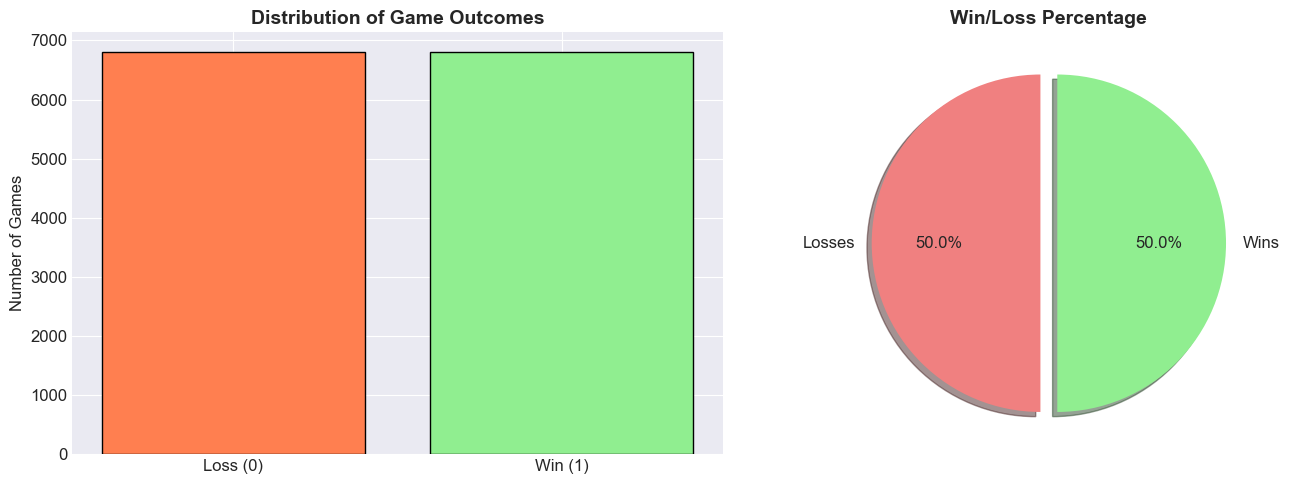

✅ Win Rate: 50.00%

📊 Win Rate by Home/Away:
   Home Games Win Rate: 55.10%
   Away Games Win Rate: 44.92%
   Home Court Advantage: +10.18%


In [14]:
# ============================================
# PART 2: TARGET VARIABLE ANALYSIS (WIN)
# ============================================

print("\n" + "="*70)
print("PART 2: TARGET VARIABLE ANALYSIS (WIN)")
print("="*70)

# Win distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
win_counts = df['win'].value_counts()
axes[0].bar(['Loss (0)', 'Win (1)'], win_counts.values, color=['coral', 'lightgreen'], edgecolor='black')
axes[0].set_title('Distribution of Game Outcomes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Games')

# Pie chart
colors = ['lightcoral', 'lightgreen']
explode = (0.05, 0.05)
axes[1].pie(win_counts.values, explode=explode, labels=['Losses', 'Wins'], colors=colors,
            autopct='%1.1f%%', shadow=True, startangle=90)
axes[1].set_title('Win/Loss Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('win_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"✅ Win Rate: {df['win'].mean()*100:.2f}%")

# Win rate by home/away
print("\n📊 Win Rate by Home/Away:")
home_win_rate = df[df['is_home'] == True]['win'].mean()
away_win_rate = df[df['is_home'] == False]['win'].mean()
print(f"   Home Games Win Rate: {home_win_rate*100:.2f}%")
print(f"   Away Games Win Rate: {away_win_rate*100:.2f}%")
print(f"   Home Court Advantage: +{(home_win_rate - away_win_rate)*100:.2f}%")


PART 3: POINTS ANALYSIS


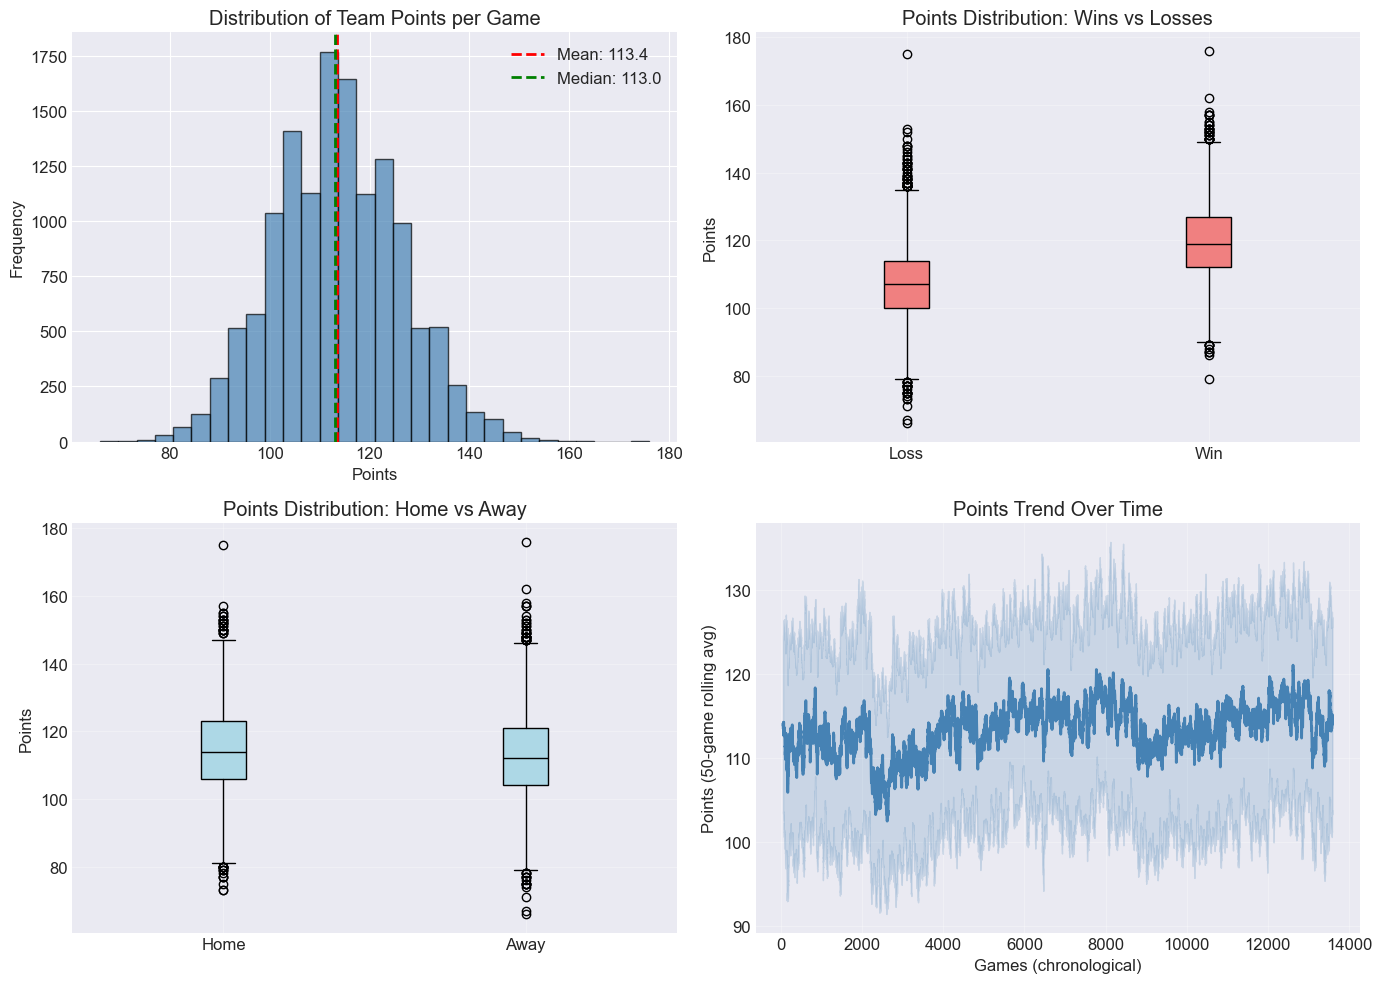


📊 Points Statistics:
   Overall Mean: 113.40
   Overall Median: 113.00
   Wins Mean: 119.52
   Losses Mean: 107.28
   Difference: +12.23


In [15]:
# ============================================
# PART 3: POINTS ANALYSIS
# ============================================

print("\n" + "="*70)
print("PART 3: POINTS ANALYSIS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Points distribution
axes[0,0].hist(df['pts'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df['pts'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['pts'].mean():.1f}")
axes[0,0].axvline(df['pts'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {df['pts'].median():.1f}")
axes[0,0].set_xlabel('Points')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Distribution of Team Points per Game')
axes[0,0].legend()

# Points by win/loss
win_pts = df[df['win'] == True]['pts']
loss_pts = df[df['win'] == False]['pts']
axes[0,1].boxplot([loss_pts, win_pts], labels=['Loss', 'Win'], patch_artist=True,
                  boxprops=dict(facecolor='lightcoral'), medianprops=dict(color='black'))
axes[0,1].set_ylabel('Points')
axes[0,1].set_title('Points Distribution: Wins vs Losses')
axes[0,1].grid(True, alpha=0.3)

# Points by home/away
home_pts = df[df['is_home'] == True]['pts']
away_pts = df[df['is_home'] == False]['pts']
axes[1,0].boxplot([home_pts, away_pts], labels=['Home', 'Away'], patch_artist=True,
                  boxprops=dict(facecolor='lightblue'), medianprops=dict(color='black'))
axes[1,0].set_ylabel('Points')
axes[1,0].set_title('Points Distribution: Home vs Away')
axes[1,0].grid(True, alpha=0.3)

# Points over time (by game date)
df_sorted = df.sort_values('game_date')
axes[1,1].plot(range(len(df_sorted)), df_sorted['pts'].rolling(50).mean(), color='steelblue', linewidth=2)
axes[1,1].fill_between(range(len(df_sorted)), 
                       df_sorted['pts'].rolling(50).mean() - df_sorted['pts'].rolling(50).std(),
                       df_sorted['pts'].rolling(50).mean() + df_sorted['pts'].rolling(50).std(),
                       alpha=0.2, color='steelblue')
axes[1,1].set_xlabel('Games (chronological)')
axes[1,1].set_ylabel('Points (50-game rolling avg)')
axes[1,1].set_title('Points Trend Over Time')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('points_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n📊 Points Statistics:")
print(f"   Overall Mean: {df['pts'].mean():.2f}")
print(f"   Overall Median: {df['pts'].median():.2f}")
print(f"   Wins Mean: {win_pts.mean():.2f}")
print(f"   Losses Mean: {loss_pts.mean():.2f}")
print(f"   Difference: +{win_pts.mean() - loss_pts.mean():.2f}")


PART 4: KEY METRICS COMPARISON (Wins vs Losses)


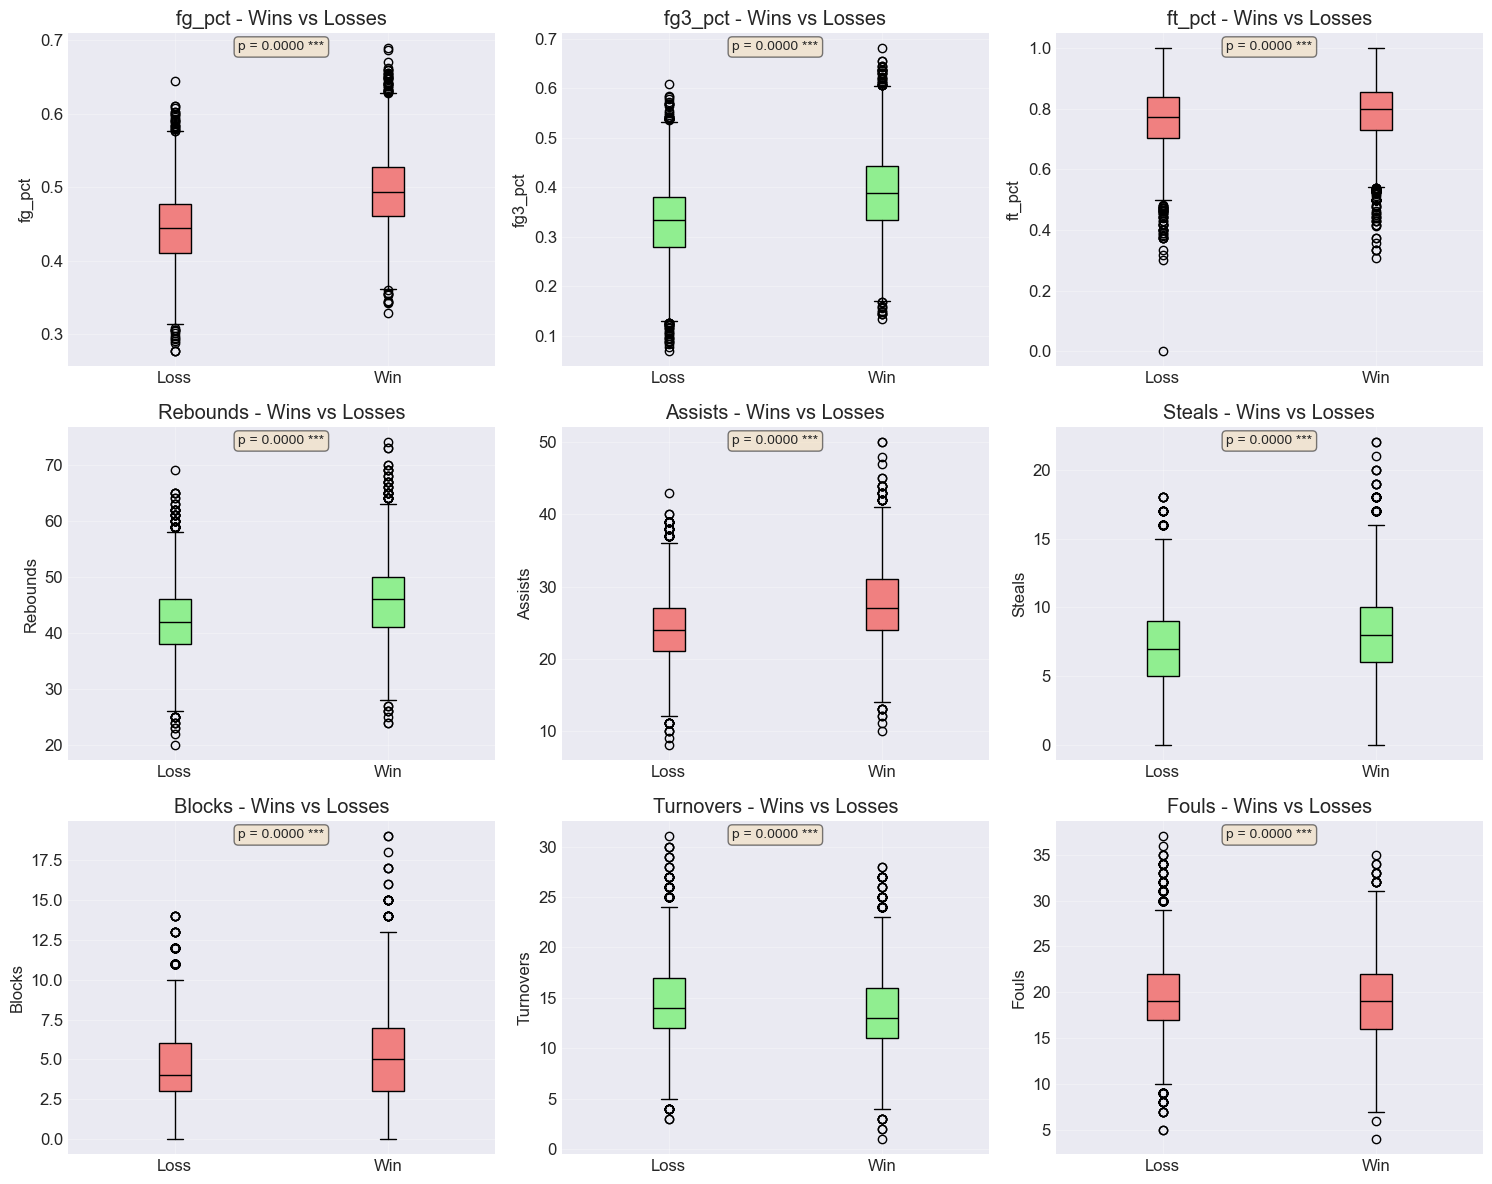


📊 Key Metrics Comparison:
   Metric Wins (Mean) Losses (Mean) Difference
   fg_pct       0.495         0.445       +0.0
  fg3_pct       0.390         0.331       +0.1
   ft_pct       0.792         0.769       +0.0
 Rebounds        45.9          42.0       +3.9
  Assists        27.3          24.1       +3.2
   Steals         8.1           7.3       +0.8
   Blocks         5.2           4.5       +0.8
Turnovers        13.6          14.4       -0.7
    Fouls        19.1          19.6       -0.6


In [16]:
# ============================================
# PART 4: KEY METRICS COMPARISON (Wins vs Losses)
# ============================================

print("\n" + "="*70)
print("PART 4: KEY METRICS COMPARISON (Wins vs Losses)")
print("="*70)

# Select key metrics to compare
key_metrics = ['pts',
 'fgm',
 'fga',
 'fg_pct',
 'fg3m',
 'fg3a',
 'fg3_pct',
 'ftm',
 'fta',
 'ft_pct',
 'oreb',
 'dreb',
 'reb',
 'ast',
 'tov',
 'stl',
 'blk',
 'blka',
 'pf',
 'pfd',
 'pace',
 'poss',
'diff_ast',
 'diff_tov',
 'diff_blk',
 'diff_blka',
 'diff_fgm',
 'diff_fga',
 'diff_ftm',
 'diff_fta',
 'diff_pf',
 'diff_pfd',
 'diff_stl',
 'diff_oreb',
 'diff_dreb',
 'diff_fg3m',
 'diff_fg3a']
metric_labels = ['pts',
 'fgm',
 'fga',
 'fg_pct',
 'fg3m',
 'fg3a',
 'fg3_pct',
 'ftm',
 'fta',
 'ft_pct',
 'oreb',
 'dreb',
 'reb',
 'ast',
 'tov',
 'stl',
 'blk',
 'blka',
 'pf',
 'pfd',
 'pace',
 'poss',

'diff_ast',
 'diff_tov',
 'diff_blk',
 'diff_blka',
 'diff_fgm',
 'diff_fga',
 'diff_ftm',
 'diff_fta',
 'diff_pf',
 'diff_pfd',
 'diff_stl',
 'diff_oreb',
 'diff_dreb',
 'diff_fg3m',
 'diff_fg3a']

# Calculate means for wins and losses
win_means = []
loss_means = []
for metric in key_metrics:
    win_means.append(df[df['win'] == True][metric].mean())
    loss_means.append(df[df['win'] == False][metric].mean())

# Create comparison bar chart
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (metric, label) in enumerate(zip(key_metrics, metric_labels)):
    # Data for this metric
    win_data = df[df['win'] == True][metric]
    loss_data = df[df['win'] == False][metric]
    
    # Box plot
    axes[i].boxplot([loss_data, win_data], labels=['Loss', 'Win'], patch_artist=True,
                   boxprops=dict(facecolor='lightcoral' if i%2==0 else 'lightgreen'),
                   medianprops=dict(color='black'))
    axes[i].set_ylabel(label)
    axes[i].set_title(f'{label} - Wins vs Losses')
    axes[i].grid(True, alpha=0.3)
    
    # Add significance indicator (t-test)
    t_stat, p_value = stats.ttest_ind(win_data, loss_data)
    sig_text = f"p = {p_value:.4f}"
    if p_value < 0.001:
        sig_text += " ***"
    elif p_value < 0.01:
        sig_text += " **"
    elif p_value < 0.05:
        sig_text += " *"
    axes[i].text(0.5, 0.95, sig_text, transform=axes[i].transAxes, ha='center', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': metric_labels,
    'Wins (Mean)': [f"{m:.3f}" if 'pct' in key_metrics[i] else f"{m:.1f}" for i, m in enumerate(win_means)],
    'Losses (Mean)': [f"{m:.3f}" if 'pct' in key_metrics[i] else f"{m:.1f}" for i, m in enumerate(loss_means)],
    'Difference': [f"{w-l:+.3f}" if 'pct' in key_metrics[i] else f"{w-l:+.1f}" for w, l in zip(win_means, loss_means)]
})

print("\n📊 Key Metrics Comparison:")
print(comparison_df.to_string(index=False))


PART 5: CORRELATION ANALYSIS


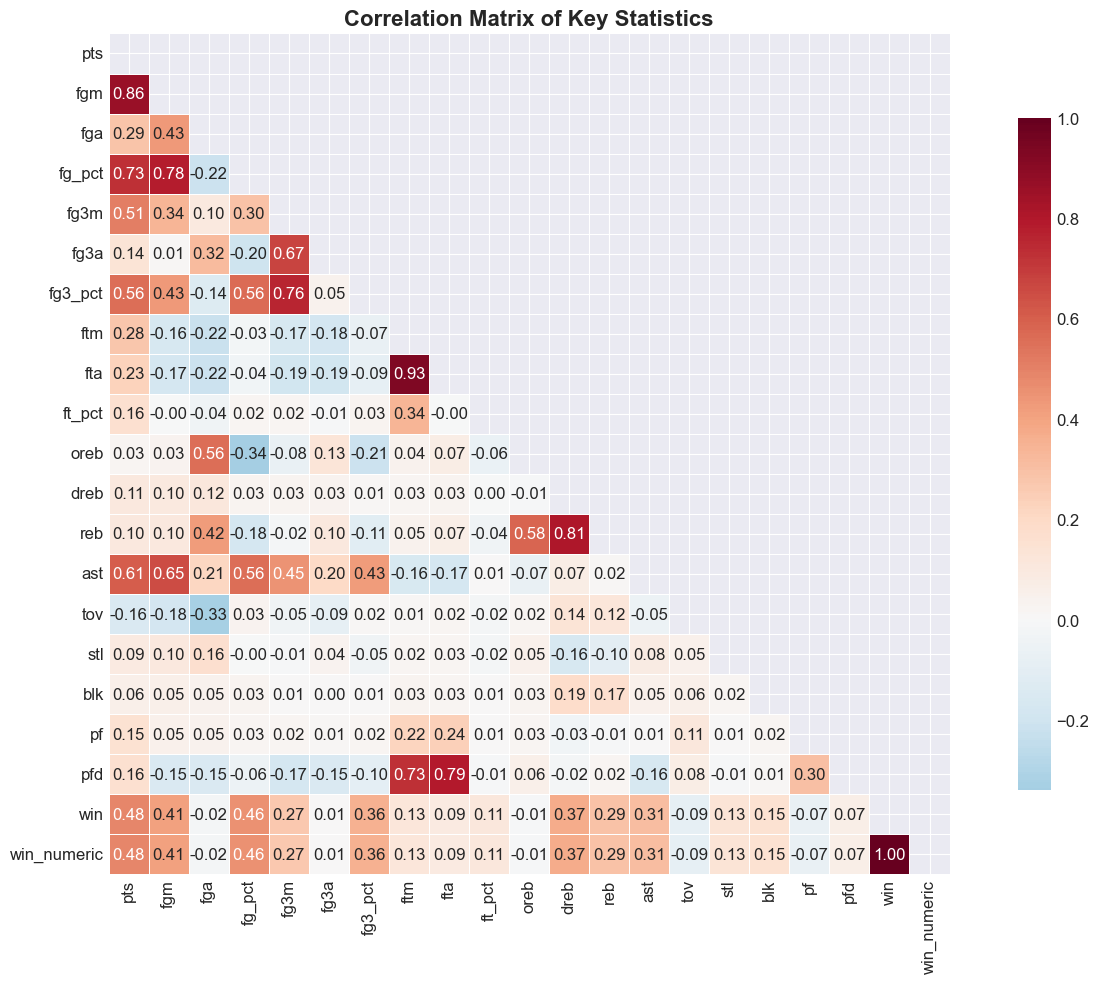


📈 Top Positive Correlations with Winning:
   1. win        : 1.0000
   2. pts        : 0.4838
   3. fg_pct     : 0.4561
   4. fgm        : 0.4111
   5. dreb       : 0.3676
   6. fg3_pct    : 0.3569
   7. ast        : 0.3127
   8. reb        : 0.2919

📉 Top Negative Correlations with Winning:
   1. fg3a       : 0.0052
   2. oreb       : -0.0125
   3. fga        : -0.0170
   4. pf         : -0.0677
   5. tov        : -0.0930


In [17]:
# ============================================
# PART 5: CORRELATION ANALYSIS
# ============================================

print("\n" + "="*70)
print("PART 5: CORRELATION ANALYSIS")
print("="*70)

# Select numerical columns for correlation
numerical_cols = ['pts', 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct',
                  'ftm', 'fta', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast',
                  'tov', 'stl', 'blk', 'pf','pfd', 'win']

# Convert win to numeric if needed
df['win_numeric'] = df['win'].astype(int)

# Calculate correlation matrix
corr_matrix = df[numerical_cols + ['win_numeric']].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Key Statistics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

# Top correlations with win
win_corr = corr_matrix['win_numeric'].drop('win_numeric').sort_values(ascending=False)
print("\n📈 Top Positive Correlations with Winning:")
for i, (col, corr) in enumerate(win_corr.head(8).items(), 1):
    print(f"   {i}. {col:10s} : {corr:.4f}")

print("\n📉 Top Negative Correlations with Winning:")
for i, (col, corr) in enumerate(win_corr.tail(5).items(), 1):
    print(f"   {i}. {col:10s} : {corr:.4f}")


PART 6: SHOOTING EFFICIENCY ANALYSIS


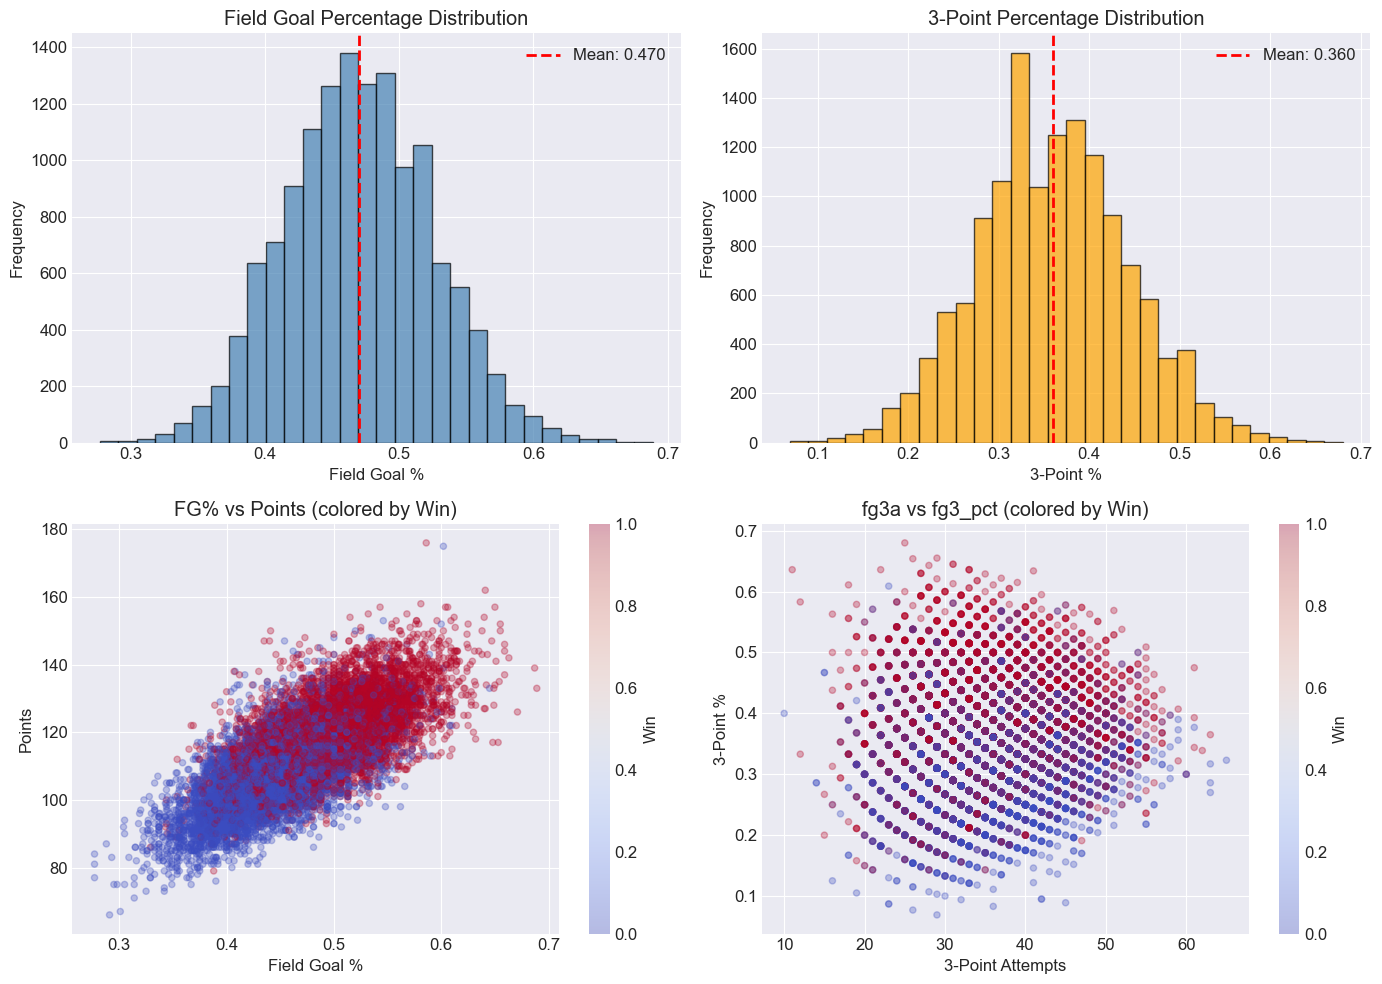

In [18]:
# ============================================
# PART 6: SHOOTING EFFICIENCY ANALYSIS
# ============================================

print("\n" + "="*70)
print("PART 6: SHOOTING EFFICIENCY ANALYSIS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# fg_pct distribution
axes[0,0].hist(df['fg_pct'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df['fg_pct'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['fg_pct'].mean():.3f}")
axes[0,0].set_xlabel('Field Goal %')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Field Goal Percentage Distribution')
axes[0,0].legend()

# fg3_pct distribution
axes[0,1].hist(df['fg3_pct'], bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[0,1].axvline(df['fg3_pct'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['fg3_pct'].mean():.3f}")
axes[0,1].set_xlabel('3-Point %')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('3-Point Percentage Distribution')
axes[0,1].legend()

# Scatter: fg_pct vs pts
axes[1,0].scatter(df['fg_pct'], df['pts'], alpha=0.3, c=df['win'], cmap='coolwarm', s=20)
axes[1,0].set_xlabel('Field Goal %')
axes[1,0].set_ylabel('Points')
axes[1,0].set_title('FG% vs Points (colored by Win)')
cbar = plt.colorbar(axes[1,0].collections[0], ax=axes[1,0])
cbar.set_label('Win')

# Scatter: fg3a vs fg3_pct
axes[1,1].scatter(df['fg3a'], df['fg3_pct'], alpha=0.3, c=df['win'], cmap='coolwarm', s=20)
axes[1,1].set_xlabel('3-Point Attempts')
axes[1,1].set_ylabel('3-Point %')
axes[1,1].set_title('fg3a vs fg3_pct (colored by Win)')
cbar = plt.colorbar(axes[1,1].collections[0], ax=axes[1,1])
cbar.set_label('Win')

plt.tight_layout()
plt.savefig('shooting_analysis.png', dpi=100, bbox_inches='tight')
plt.show()


PART 7: TEAM PERFORMANCE ANALYSIS

📊 Top 10 Teams by Win Rate:
     Team  Win Rate  Avg Points  Avg Rebounds  Avg Assists  fg_pct  fg3_pct
  Celtics     66.89      115.82         45.48        25.44    0.47     0.37
  Nuggets     63.66      116.39         44.14        28.74    0.50     0.37
     Suns     60.93      114.58         43.73        27.00    0.48     0.37
    Bucks     60.53      116.71         45.56        25.53    0.48     0.38
Cavaliers     57.71      112.81         43.49        26.37    0.48     0.36
   Knicks     57.40      112.39         45.26        24.03    0.46     0.37
 Clippers     57.30      112.82         43.28        24.49    0.48     0.38
 Warriors     57.05      115.13         44.79        28.63    0.47     0.37
    76ers     56.29      113.06         42.28        24.23    0.47     0.36
  Thunder     55.51      114.32         44.24        24.70    0.47     0.36

📊 Bottom 5 Teams by Win Rate:
         Team  Win Rate  Avg Points  Avg Rebounds  Avg Assists  fg_pc

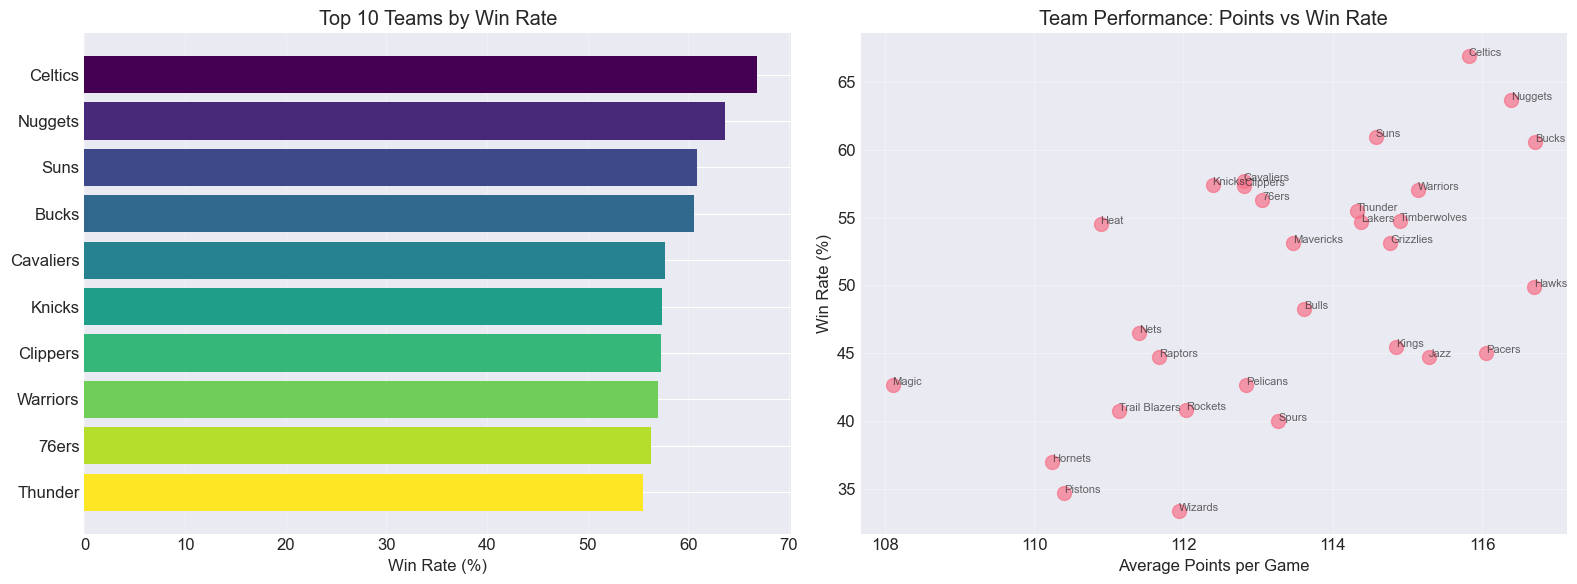

In [19]:
# ============================================
# PART 7: TEAM PERFORMANCE ANALYSIS
# ============================================

print("\n" + "="*70)
print("PART 7: TEAM PERFORMANCE ANALYSIS")
print("="*70)

# Calculate team statistics
team_stats = df.groupby('team_name').agg({
    'win': 'mean',
    'pts': 'mean',
    'reb': 'mean',
    'ast': 'mean',
    'fg_pct': 'mean',
    'fg3_pct': 'mean'
}).sort_values('win', ascending=False).reset_index()

team_stats.columns = ['Team', 'Win Rate', 'Avg Points', 'Avg Rebounds', 'Avg Assists', 'fg_pct', 'fg3_pct']
team_stats['Win Rate'] = team_stats['Win Rate'] * 100

print("\n📊 Top 10 Teams by Win Rate:")
print(team_stats.head(10).to_string(index=False, float_format="%.2f"))

print("\n📊 Bottom 5 Teams by Win Rate:")
print(team_stats.tail(5).to_string(index=False, float_format="%.2f"))

# Plot top teams
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Win rate by team
top_teams = team_stats.head(10)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_teams)))
axes[0].barh(top_teams['Team'][::-1], top_teams['Win Rate'][::-1], color=colors[::-1])
axes[0].set_xlabel('Win Rate (%)')
axes[0].set_title('Top 10 Teams by Win Rate')
axes[0].grid(True, alpha=0.3, axis='x')

# Points vs Win Rate
axes[1].scatter(team_stats['Avg Points'], team_stats['Win Rate'], alpha=0.7, s=100)
for idx, row in team_stats.iterrows():
    axes[1].annotate(row['Team'], (row['Avg Points'], row['Win Rate']), fontsize=8, alpha=0.7)
axes[1].set_xlabel('Average Points per Game')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_title('Team Performance: Points vs Win Rate')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('team_performance.png', dpi=100, bbox_inches='tight')
plt.show()


PART 8: TIME-BASED ANALYSIS


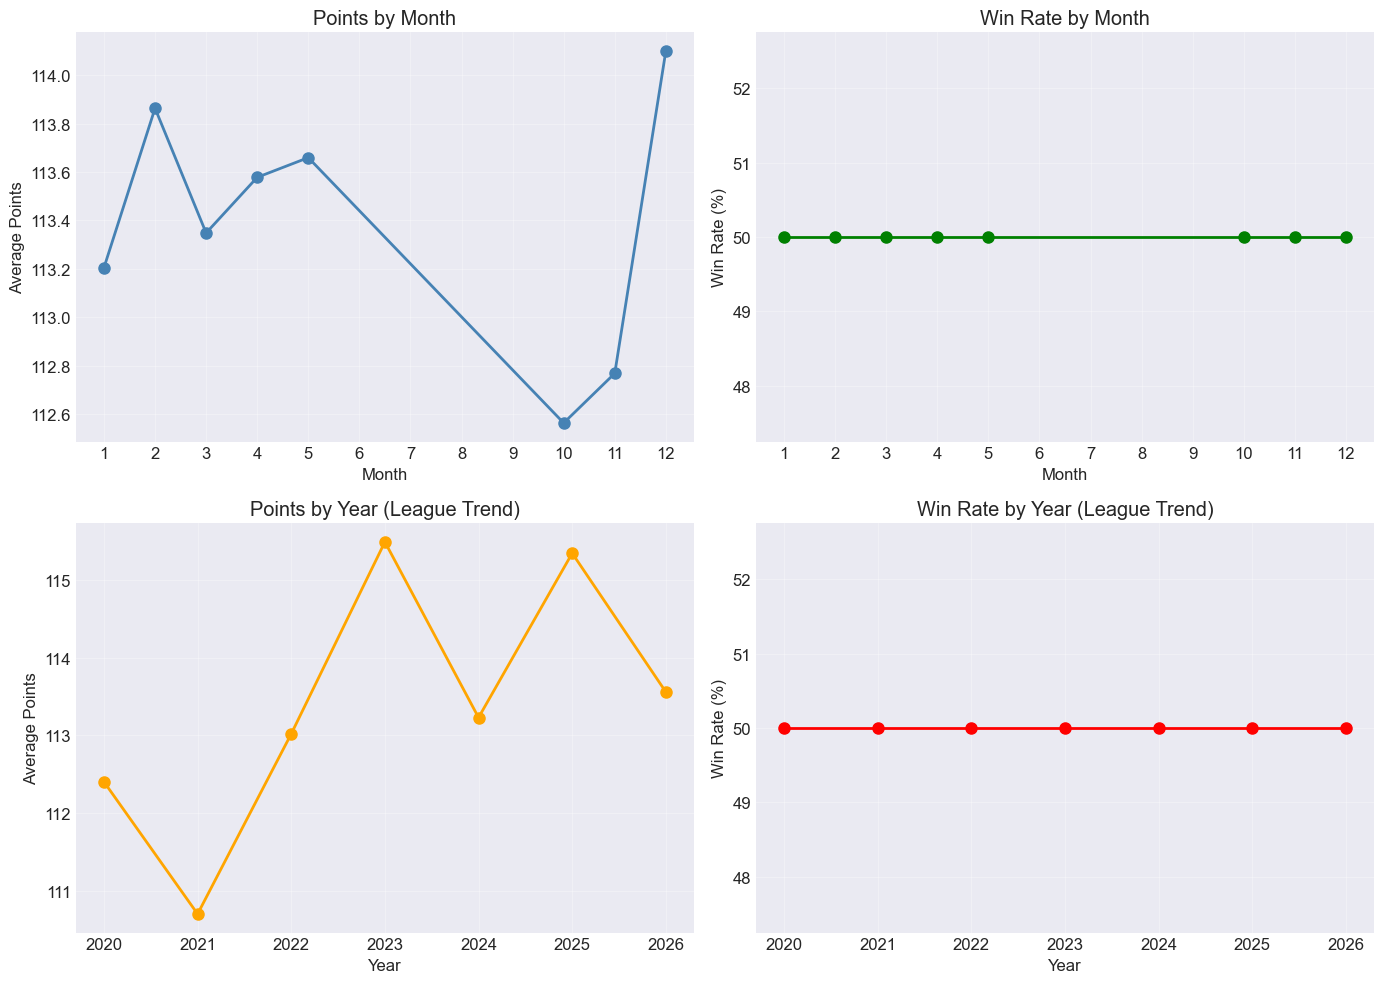

In [20]:
# ============================================
# PART 8: TIME-BASED ANALYSIS
# ============================================

print("\n" + "="*70)
print("PART 8: TIME-BASED ANALYSIS")
print("="*70)

# Convert game_date to datetime
df['game_date'] = pd.to_datetime(df['game_date'])
df['year'] = df['game_date'].dt.year
df['month'] = df['game_date'].dt.month

# Seasonal patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Points by month
monthly_pts = df.groupby('month')['pts'].mean()
axes[0,0].plot(monthly_pts.index, monthly_pts.values, 'o-', linewidth=2, markersize=8, color='steelblue')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Average Points')
axes[0,0].set_title('Points by Month')
axes[0,0].set_xticks(range(1, 13))
axes[0,0].grid(True, alpha=0.3)

# Win rate by month
monthly_win = df.groupby('month')['win'].mean() * 100
axes[0,1].plot(monthly_win.index, monthly_win.values, 'o-', linewidth=2, markersize=8, color='green')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Win Rate (%)')
axes[0,1].set_title('Win Rate by Month')
axes[0,1].set_xticks(range(1, 13))
axes[0,1].grid(True, alpha=0.3)

# Points by year
yearly_pts = df.groupby('year')['pts'].mean()
axes[1,0].plot(yearly_pts.index, yearly_pts.values, 'o-', linewidth=2, markersize=8, color='orange')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Average Points')
axes[1,0].set_title('Points by Year (League Trend)')
axes[1,0].grid(True, alpha=0.3)

# Win rate by year
yearly_win = df.groupby('year')['win'].mean() * 100
axes[1,1].plot(yearly_win.index, yearly_win.values, 'o-', linewidth=2, markersize=8, color='red')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Win Rate (%)')
axes[1,1].set_title('Win Rate by Year (League Trend)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('time_analysis.png', dpi=100, bbox_inches='tight')
plt.show()


PART 9: OUTLIER DETECTION


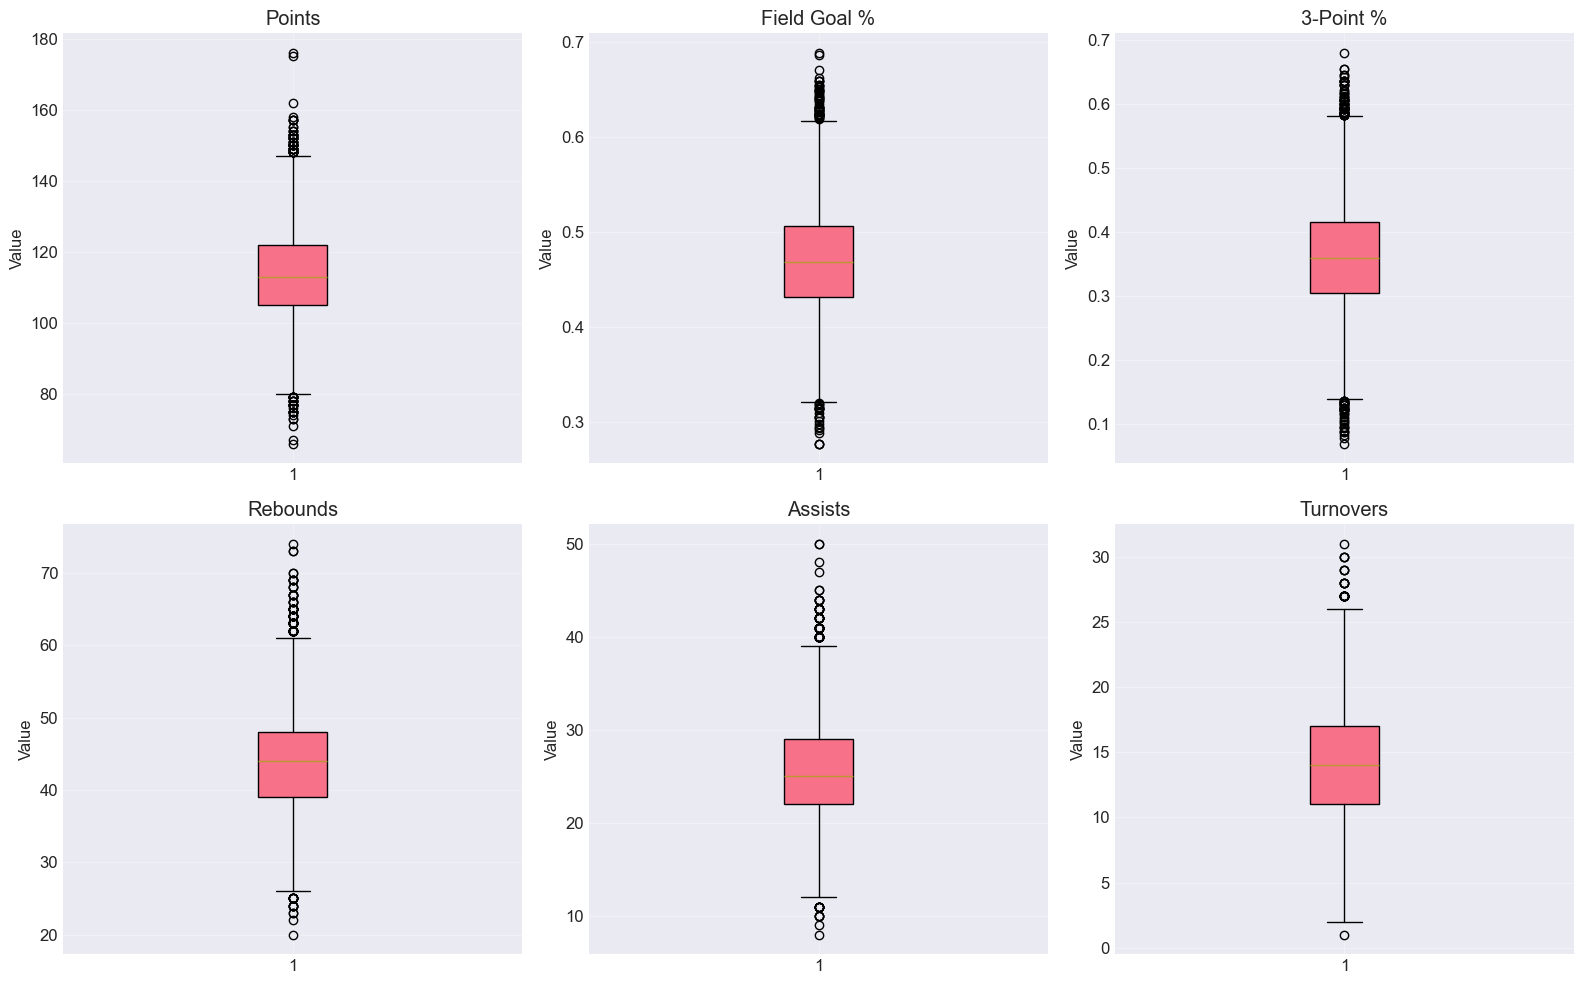


📊 Outlier Analysis (Points):
   Normal range: 79.5 - 147.5 points
   Number of outliers: 87 (0.64%)
   Highest score: 176
   Lowest score: 66


In [21]:
# ============================================
# PART 9: OUTLIER DETECTION
# ============================================

print("\n" + "="*70)
print("PART 9: OUTLIER DETECTION")
print("="*70)

# Box plots for key metrics
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
metrics = ['pts', 'fg_pct', 'fg3_pct', 'reb', 'ast', 'tov']
titles = ['Points', 'Field Goal %', '3-Point %', 'Rebounds', 'Assists', 'Turnovers']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    row, col = i // 3, i % 3
    axes[row, col].boxplot(df[metric], vert=True, patch_artist=True)
    axes[row, col].set_title(title)
    axes[row, col].set_ylabel('Value')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=100, bbox_inches='tight')
plt.show()

# Identify outliers using IQR
print("\n📊 Outlier Analysis (Points):")
Q1 = df['pts'].quantile(0.25)
Q3 = df['pts'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['pts'] < lower_bound) | (df['pts'] > upper_bound)]
print(f"   Normal range: {lower_bound:.1f} - {upper_bound:.1f} points")
print(f"   Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"   Highest score: {df['pts'].max()}")
print(f"   Lowest score: {df['pts'].min()}")

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

# ============================================
# PART 1: CALCULATE REST DAYS FOR EACH TEAM
# ============================================

print("="*70)
print("PART 1: CALCULATING REST DAYS BETWEEN GAMES")
print("="*70)

# Ensure game_date is datetime
df['game_date'] = pd.to_datetime(df['game_date'])

# Sort by team and date to calculate rest days
df = df.sort_values(['team_name', 'game_date']).reset_index(drop=True)

# Calculate days since last game for each team
df['days_rest'] = df.groupby('team_name')['game_date'].diff().dt.days

# First game of season for each team will have NaN - fill with reasonable value
# Typically teams have 3-4 months rest before season starts
df['days_rest'] = df['days_rest'].fillna(120)  # Approximate offseason rest

# Create rest categories
def categorize_rest(days):
    if days <= 1:
        return 'Back-to-Back(less than 1 day)'  # Common, meaningful category
    elif days == 2:
        return '1 Day Rest'  # Most common, keep separate
    elif days == 3:
        return '2 Days Rest'  # Common, keep separate
    elif 4 <= days <= 7:
        # Group these because:
        # 1. Small sample sizes individually
        # 2. Similar physiological recovery
        # 3. Often include special circumstances (All-Star break)
        return 'Extended Rest (4-7 days)'
    else:
        return 'Offseason/Extended Break (8+ days)'

df['rest_category'] = df['days_rest'].apply(categorize_rest)

print(f"\n📊 Rest days statistics:")
print(f"   Mean rest: {df['days_rest'].mean():.1f} days")
print(f"   Median rest: {df['days_rest'].median():.1f} days")
print(f"   Min rest: {df['days_rest'].min():.0f} days")
print(f"   Max rest: {df['days_rest'].max():.0f} days")

# Distribution of rest days
print("\n📈 Rest days distribution:")
rest_dist = df['rest_category'].value_counts().sort_index()
for category, count in rest_dist.items():
    pct = count/len(df)*100
    print(f"   {category:25s}: {count:5d} games ({pct:.1f}%)")

PART 1: CALCULATING REST DAYS BETWEEN GAMES

📊 Rest days statistics:
   Mean rest: 4.4 days
   Median rest: 2.0 days
   Min rest: 1 days
   Max rest: 200 days

📈 Rest days distribution:
   1 Day Rest               :  8512 games (62.6%)
   2 Days Rest              :  1879 games (13.8%)
   Back-to-Back(less than 1 day):  2427 games (17.9%)
   Extended Rest (4-7 days) :   464 games (3.4%)
   Offseason/Extended Break (8+ days):   314 games (2.3%)



PART 2: IMPACT OF REST ON PERFORMANCE

📊 Performance by Rest Days:
                     rest_category  win_mean  win_count  pts_mean  fg_pct_mean  reb_mean  ast_mean  tov_mean
                        1 Day Rest     50.70       8512    113.43         0.47     43.95     25.78     13.99
                       2 Days Rest     52.60       1879    113.98         0.47     44.12     26.01     14.02
     Back-to-Back(less than 1 day)     45.00       2427    112.29         0.47     43.60     25.29     13.88
          Extended Rest (4-7 days)     51.90        464    115.50         0.47     44.27     26.34     14.28
Offseason/Extended Break (8+ days)     50.30        314    114.50         0.47     45.42     25.12     14.65


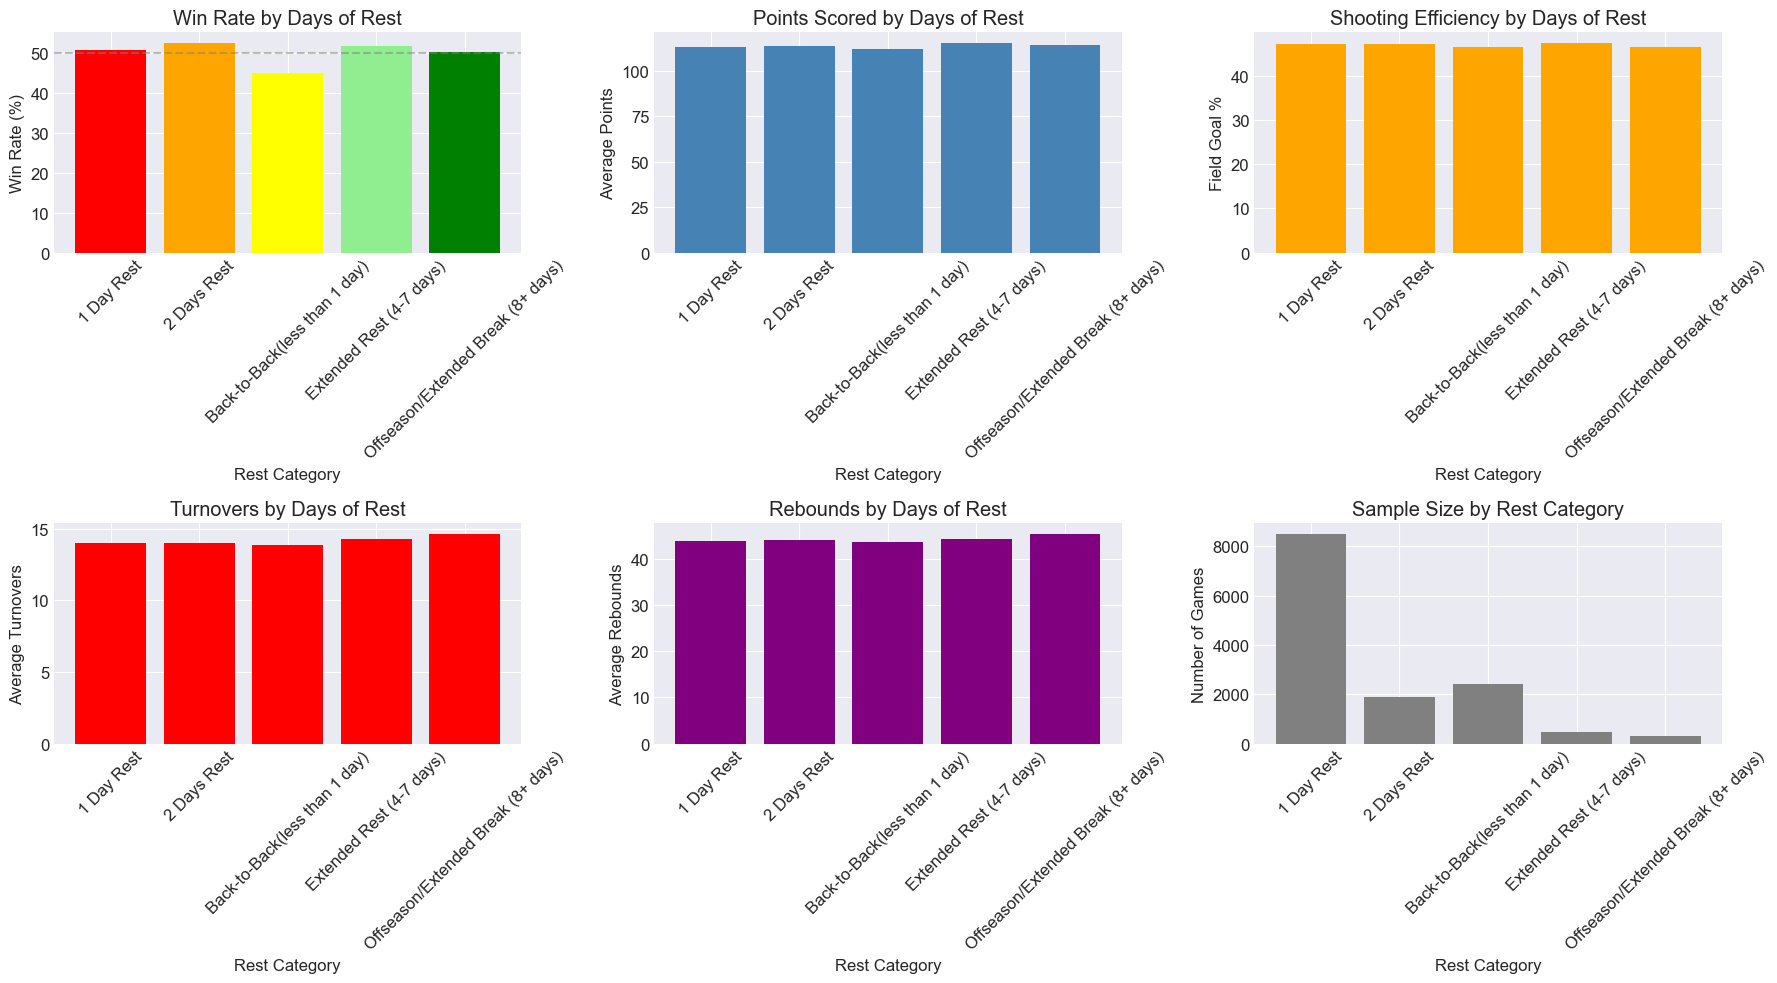

In [23]:
print("\n" + "="*70)
print("PART 2: IMPACT OF REST ON PERFORMANCE")
print("="*70)

# Group by rest category
rest_analysis = df.groupby('rest_category').agg({
    'win': ['mean', 'count'],
    'pts': 'mean',
    'fg_pct': 'mean',
    'reb': 'mean',
    'ast': 'mean',
    'tov': 'mean'
}).round(3)

# Flatten column names
rest_analysis.columns = ['_'.join(col).strip() for col in rest_analysis.columns.values]
rest_analysis = rest_analysis.reset_index()
rest_analysis['win_mean'] = rest_analysis['win_mean'] * 100  # Convert to percentage

print("\n📊 Performance by Rest Days:")
print(rest_analysis.to_string(index=False, float_format="%.2f"))

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Win Rate by Rest
axes[0,0].bar(rest_analysis['rest_category'], rest_analysis['win_mean'], 
              color=['red', 'orange', 'yellow', 'lightgreen', 'green', 'darkgreen'])
axes[0,0].set_xlabel('Rest Category')
axes[0,0].set_ylabel('Win Rate (%)')
axes[0,0].set_title('Win Rate by Days of Rest')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].axhline(y=50, color='gray', linestyle='--', alpha=0.5)

# 2. Points by Rest
axes[0,1].bar(rest_analysis['rest_category'], rest_analysis['pts_mean'],
              color='steelblue')
axes[0,1].set_xlabel('Rest Category')
axes[0,1].set_ylabel('Average Points')
axes[0,1].set_title('Points Scored by Days of Rest')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. FG% by Rest
axes[0,2].bar(rest_analysis['rest_category'], rest_analysis['fg_pct_mean'] * 100,
              color='orange')
axes[0,2].set_xlabel('Rest Category')
axes[0,2].set_ylabel('Field Goal %')
axes[0,2].set_title('Shooting Efficiency by Days of Rest')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Turnovers by Rest
axes[1,0].bar(rest_analysis['rest_category'], rest_analysis['tov_mean'],
              color='red')
axes[1,0].set_xlabel('Rest Category')
axes[1,0].set_ylabel('Average Turnovers')
axes[1,0].set_title('Turnovers by Days of Rest')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Rebounds by Rest
axes[1,1].bar(rest_analysis['rest_category'], rest_analysis['reb_mean'],
              color='purple')
axes[1,1].set_xlabel('Rest Category')
axes[1,1].set_ylabel('Average Rebounds')
axes[1,1].set_title('Rebounds by Days of Rest')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Sample size
axes[1,2].bar(rest_analysis['rest_category'], rest_analysis['win_count'],
              color='gray')
axes[1,2].set_xlabel('Rest Category')
axes[1,2].set_ylabel('Number of Games')
axes[1,2].set_title('Sample Size by Rest Category')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('rest_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

# ============================================
# PART 1: CALCULATE ROLLING AVERAGES
# ============================================

print("="*70)
print("PART 1: CALCULATING ROLLING AVERAGES (LAST 5 GAMES)")
print("="*70)

# Ensure data is sorted chronologically for each team
df = df.sort_values(['team_name', 'game_date']).reset_index(drop=True)

# Define the metrics we want rolling averages for
rolling_metrics = ['pts', 'fg_pct', 'fg3_pct', 'reb', 'ast', 'stl', 'blk', 'tov', 'pf']
window = 5  # 5-game rolling average

# Calculate rolling averages for each team
for metric in rolling_metrics:
    df[f'{metric}_rolling_5'] = df.groupby('team_name')[metric].transform(
        lambda x: x.rolling(window, min_periods=1).mean().shift(1)  # Shift to avoid look-ahead bias
    )

print("✅ Created rolling averages for:", ', '.join([f'{m}_rolling_5' for m in rolling_metrics]))

# Show example for one team
example_team = 'Lakers' if 'Lakers' in df['team_name'].values else df['team_name'].iloc[0]
team_example = df[df['team_name'] == example_team].head(10)[
    ['game_date', 'team_name', 'pts', 'pts_rolling_5'] + 
    [f'{m}_rolling_5' for m in rolling_metrics[:3]]
]

print(f"\n📋 Example: {example_team} - First 10 games")
print(team_example.to_string(index=False))

PART 1: CALCULATING ROLLING AVERAGES (LAST 5 GAMES)
✅ Created rolling averages for: pts_rolling_5, fg_pct_rolling_5, fg3_pct_rolling_5, reb_rolling_5, ast_rolling_5, stl_rolling_5, blk_rolling_5, tov_rolling_5, pf_rolling_5

📋 Example: Lakers - First 10 games
 game_date team_name  pts  pts_rolling_5  pts_rolling_5  fg_pct_rolling_5  fg3_pct_rolling_5
2020-12-22    Lakers  109            NaN            NaN               NaN                NaN
2020-12-25    Lakers  138     109.000000     109.000000          0.469000           0.310000
2020-12-27    Lakers  127     123.500000     123.500000          0.514500           0.398500
2020-12-28    Lakers  107     124.666667     124.666667          0.528333           0.389333
2020-12-30    Lakers  121     120.250000     120.250000          0.514000           0.384500
2021-01-01    Lakers  109     120.400000     120.400000          0.523400           0.415200
2021-01-03    Lakers  108     120.400000     120.400000          0.510800           0.438


PART 3: TEAM MOMENTUM VISUALIZATION


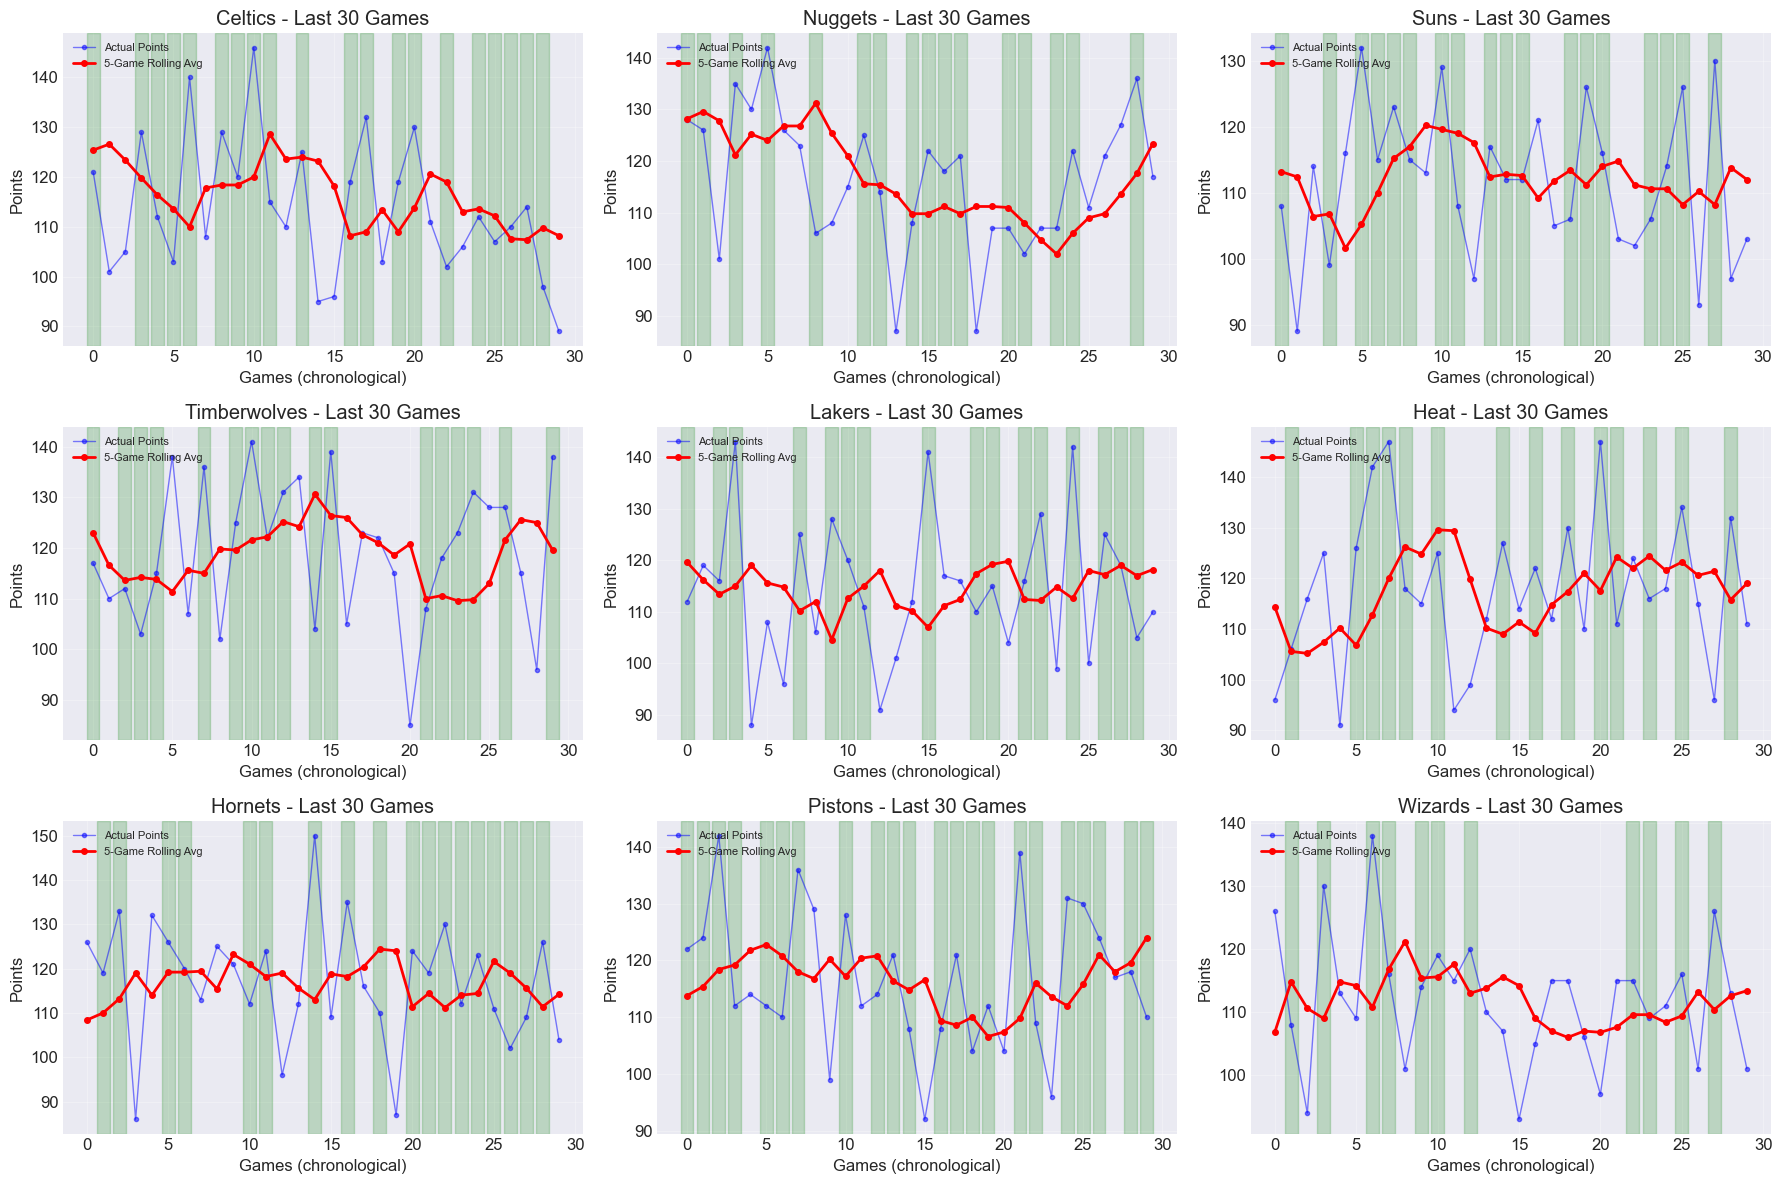

In [25]:
print("\n" + "="*70)
print("PART 3: TEAM MOMENTUM VISUALIZATION")
print("="*70)

# Pick a few teams to visualize
top_teams = df.groupby('team_name')['win'].mean().sort_values(ascending=False).head(3).index.tolist()
mid_teams = df.groupby('team_name')['win'].mean().sort_values(ascending=False).iloc[10:13].index.tolist()
bottom_teams = df.groupby('team_name')['win'].mean().sort_values(ascending=False).tail(3).index.tolist()

selected_teams = top_teams + mid_teams + bottom_teams

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, team in enumerate(selected_teams[:9]):
    team_data = df[df['team_name'] == team].copy()
    team_data = team_data.sort_values('game_date').tail(30)  # Last 30 games
    
    # Plot actual vs rolling
    axes[idx].plot(range(len(team_data)), team_data['pts'], 'o-', alpha=0.5, 
                   label='Actual Points', color='blue', linewidth=1, markersize=3)
    axes[idx].plot(range(len(team_data)), team_data['pts_rolling_5'], 'o-', 
                   label='5-Game Rolling Avg', color='red', linewidth=2, markersize=4)
    
    # Shade winning games
    for i, (_, row) in enumerate(team_data.iterrows()):
        if row['win']:
            axes[idx].axvspan(i-0.4, i+0.4, alpha=0.2, color='green')
    
    axes[idx].set_title(f'{team} - Last 30 Games')
    axes[idx].set_xlabel('Games (chronological)')
    axes[idx].set_ylabel('Points')
    axes[idx].legend(loc='upper left', fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('team_momentum.png', dpi=100, bbox_inches='tight')
plt.show()


#add the team they played

In [27]:
print("\n" + "="*70)
print("PART 3: TEAM MOMENTUM VISUALIZATION (WITH OPPONENT DATA)")
print("="*70)

# Step 1: Create a function to get opponent name for each row
def get_opponent_name(row):
    """
    Returns the opponent team name based on whether the team is home or away
    """
    if row['is_home']:  # If current team is home team
        return row['away_team_name']  # Opponent is away team
    else:  # If current team is away team
        # Opponent is home team - we need to find which team is home
        # We can get this from the game data
        # For now, we'll need to merge with game data to get home_team_name
        return "Unknown"  # Placeholder - we'll fix this

# Step 2: First, add home_team_name to df by merging with team_df
# Create a mapping of team_id to team_name
team_id_to_name = team_df.set_index('team_id')['team_name'].to_dict()

# Add home_team_name to df by merging with game_df
df = pd.merge(
    df,
    game_df[['game_id', 'home_team_id', 'away_team_id']],
    on='game_id',
    how='left'
)

# Convert team_ids to team names
df['home_team_name'] = df['home_team_id'].map(team_id_to_name)
df['away_team_name'] = df['away_team_name']  # Already have this

# Step 3: Now we can correctly identify opponent for every row
def get_correct_opponent(row):
    """
    Returns the correct opponent name for any team row
    """
    if row['is_home']:
        # If current team is home, opponent is away team
        return row['away_team_name']
    else:
        # If current team is away, opponent is home team
        return row['home_team_name']

df['opponent_name'] = df.apply(get_correct_opponent, axis=1)

# Verify it worked
print("\n✅ Created opponent_name column - verifying with samples:")
verification = df[['team_name', 'is_home', 'home_team_name', 'away_team_name', 'opponent_name']].head(10)
print(verification.to_string(index=False))

# Step 4: Calculate rolling averages for both team and opponent
print("\n📊 Calculating rolling averages...")

# First, ensure data is sorted
df = df.sort_values(['team_name', 'game_date']).reset_index(drop=True)

# Calculate team's rolling averages
window = 5
for metric in ['pts', 'fg_pct', 'fg3_pct', 'reb', 'ast']:
    df[f'{metric}_rolling_5'] = df.groupby('team_name')[metric].transform(
        lambda x: x.rolling(window, min_periods=1).mean().shift(1)
    )

# Step 5: Create a separate dataframe for opponent rolling averages
print("   Calculating opponent rolling averages...")

# Create a dataframe with all team-game records (like a master copy)
all_team_games = df[['game_id', 'team_name', 'game_date', 'pts', 'fg_pct', 'fg3_pct', 'reb', 'ast']].copy()
all_team_games = all_team_games.sort_values(['team_name', 'game_date'])

# Calculate rolling averages for every team
for metric in ['pts', 'fg_pct', 'fg3_pct', 'reb', 'ast']:
    all_team_games[f'{metric}_rolling_5'] = all_team_games.groupby('team_name')[metric].transform(
        lambda x: x.rolling(window, min_periods=1).mean().shift(1)
    )

# Step 6: Merge opponent rolling averages into main dataframe
# For each game, we need to get the opponent's rolling averages
opponent_rolling = all_team_games[['game_id', 'team_name', 'pts_rolling_5', 'fg_pct_rolling_5', 
                                   'fg3_pct_rolling_5', 'reb_rolling_5', 'ast_rolling_5']].copy()
opponent_rolling.columns = ['game_id', 'opponent_name', 'opp_pts_rolling_5', 'opp_fg_pct_rolling_5',
                            'opp_fg3_pct_rolling_5', 'opp_reb_rolling_5', 'opp_ast_rolling_5']

# Merge using game_id and opponent_name
df = pd.merge(
    df,
    opponent_rolling,
    on=['game_id', 'opponent_name'],
    how='left'
)

# Also add opponent's actual points for current game
opponent_actual = all_team_games[['game_id', 'team_name', 'pts']].copy()
opponent_actual.columns = ['game_id', 'opponent_name', 'opp_actual_pts']

df = pd.merge(
    df,
    opponent_actual,
    on=['game_id', 'opponent_name'],
    how='left'
)

print("✅ Successfully added opponent rolling averages and actual points")


PART 3: TEAM MOMENTUM VISUALIZATION (WITH OPPONENT DATA)

✅ Created opponent_name column - verifying with samples:
team_name  is_home home_team_name away_team_name opponent_name
    76ers     True          76ers        Wizards       Wizards
    76ers    False         Knicks          76ers        Knicks
    76ers    False      Cavaliers          76ers     Cavaliers
    76ers     True          76ers        Raptors       Raptors
    76ers    False          Magic          76ers         Magic
    76ers     True          76ers        Hornets       Hornets
    76ers     True          76ers        Hornets       Hornets
    76ers     True          76ers        Wizards       Wizards
    76ers    False           Nets          76ers          Nets
    76ers     True          76ers        Nuggets       Nuggets

📊 Calculating rolling averages...
   Calculating opponent rolling averages...
✅ Successfully added opponent rolling averages and actual points



PART 3: TEAM MOMENTUM VISUALIZATION (WITH OPPONENT DATA)


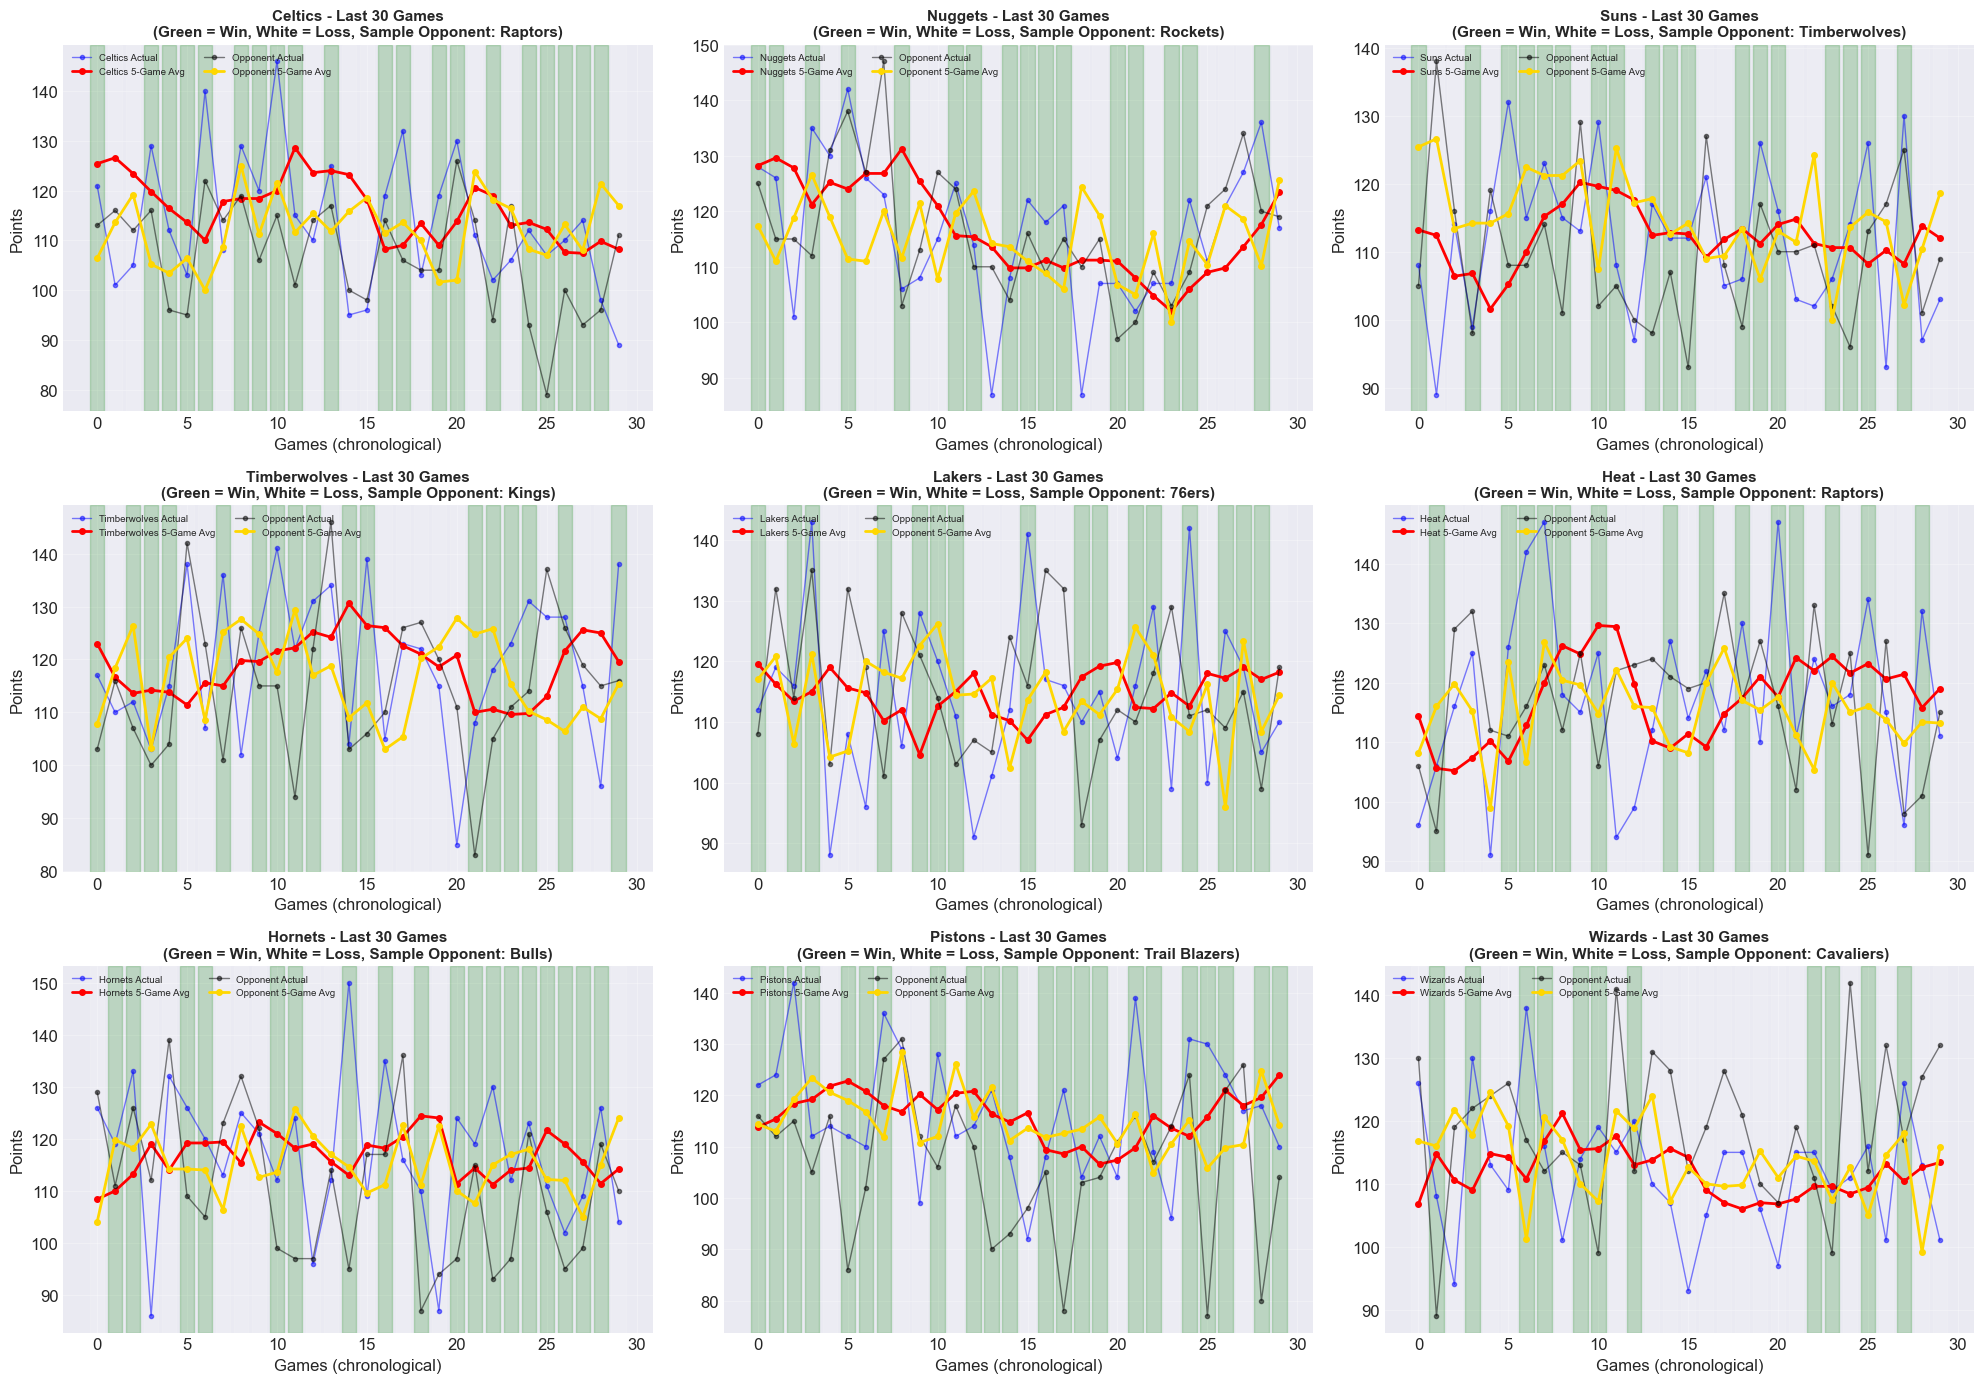

In [30]:
print("\n" + "="*70)
print("PART 3: TEAM MOMENTUM VISUALIZATION (WITH OPPONENT DATA)")
print("="*70)

# Pick teams to visualize
top_teams = df.groupby('team_name')['win'].mean().sort_values(ascending=False).head(3).index.tolist()
mid_teams = df.groupby('team_name')['win'].mean().sort_values(ascending=False).iloc[10:13].index.tolist()
bottom_teams = df.groupby('team_name')['win'].mean().sort_values(ascending=False).tail(3).index.tolist()

selected_teams = top_teams + mid_teams + bottom_teams

fig, axes = plt.subplots(3, 3, figsize=(20, 14))
axes = axes.flatten()

for idx, team in enumerate(selected_teams[:9]):
    team_data = df[df['team_name'] == team].copy()
    team_data = team_data.sort_values('game_date').tail(30)  # Last 30 games
    
    # Plot team's actual points
    axes[idx].plot(range(len(team_data)), team_data['pts'], 'o-', 
                   alpha=0.5, label=f'{team} Actual', 
                   color='blue', linewidth=1, markersize=3)
    
    # Plot team's rolling average
    axes[idx].plot(range(len(team_data)), team_data['pts_rolling_5'], 'o-', 
                   label=f'{team} 5-Game Avg', 
                   color='red', linewidth=2, markersize=4)
    
    # Plot opponent's actual points
    axes[idx].plot(range(len(team_data)), team_data['opp_actual_pts'], 'o-', 
                   alpha=0.5, label='Opponent Actual', 
                   color='black', linewidth=1, markersize=3)
    
    # Plot opponent's rolling average
    axes[idx].plot(range(len(team_data)), team_data['opp_pts_rolling_5'], 'o-', 
                   label='Opponent 5-Game Avg', 
                   color='gold', linewidth=2, markersize=4)
    
    # Shade winning games
    for i, (_, row) in enumerate(team_data.iterrows()):
        if row['win']:
            axes[idx].axvspan(i-0.4, i+0.4, alpha=0.2, color='green')
        else:
            axes[idx].axvspan(i-0.4, i+0.4, alpha=0.1, color='white')
    
    # Add opponent name in title for context
    sample_opponent = team_data['opponent_name'].iloc[0] if len(team_data) > 0 else "Unknown"
    
    axes[idx].set_title(f'{team} - Last 30 Games\n(Green = Win, White = Loss, Sample Opponent: {sample_opponent})', 
                        fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Games (chronological)')
    axes[idx].set_ylabel('Points')
    axes[idx].legend(loc='upper left', fontsize=7, ncol=2)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('team_momentum_with_opponents_fixed.png', dpi=150, bbox_inches='tight')
plt.show()